# 1. Library imports

In [1]:
import os
from IPython.display import display
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import kstest, skew, kurtosis

from volatility_pipeline.models import tuned_factory
from volatility_pipeline.models import (
    RealizedGARCH, make_realized_garch,
    GARCHModel, make_garch, XGBVolatilityModel, XGBHybridModel,
    LSTMVolatilityModel, LSTMHybridModel,
    param_matrix,
    pvalue_matrix, asymmetry_summary, persistence, equations_markdown, scale_note,
)
from volatility_pipeline.evaluation import (
    RollingEvaluator,
    ForecastResult,
    dm_matrix,
    dm_family_split,
    mcs,
    arch_mcs,
    garman_klass,
    parkinson,
    squared_returns,
    compute_proxy,
    overnight_gap_report,
    yang_zhang,
    forecast_diagnostics,
    normality_report,
    residual_report,
    residual_diagnostics_table,
)


# 2. Configuration

In [2]:
# ── Input data ───────────────────────────────────────────────────────────────
TICKER          = "BZ=F"
FULL_DATA_START = "2010-01-01"
FULL_DATA_END   = "2026-06-30"

TRAIN_START = FULL_DATA_START
TRAIN_END   = "2022-06-30"
TEST_START  = "2022-07-01"
TEST_END    = FULL_DATA_END

# ── Classical econometric model specifications ────────────────────────────────
# Each tuple: (model_type, error_distribution)
# model_type:  'GARCH' | 'GJR-GARCH' | 'EGARCH' | 'APARCH' | 'FIGARCH'
# dist:        'normal' | 't' | 'ged'
GARCH_SPECS = [
    ("GARCH",     "normal"),
    ("GARCH",     "t"),
    ("GARCH",     "ged"),
    ("GJR-GARCH", "normal"),
    ("GJR-GARCH", "t"),
    ("GJR-GARCH", "ged"),
    ("EGARCH",    "normal"),
    ("EGARCH",    "t"),
    ("EGARCH",    "ged"),
    ("APARCH",    "normal"),
    ("APARCH",    "t"),
    ("APARCH",    "ged"),
    ("FIGARCH",   "normal"),
    ("FIGARCH",   "t"),
    ("FIGARCH",   "ged"),
]

# ASYM_ORDER sets the asymmetric (leverage) order `o` of the EGARCH and APARCH
# specifications, which are asymmetric by construction in the literature
# (Nelson 1991; Ding et al. 1993):
#   1 -> asymmetric: a leverage coefficient gamma is estimated (default)
#   0 -> symmetric variants instead (log-variance GARCH / plain Power ARCH)
# It is applied ONLY to EGARCH and APARCH. GARCH and GJR-GARCH are *defined* by
# o=0 and o=1 respectively (changing o would turn one into the other), and
# arch's FIGARCH has no asymmetric term — make_garch ignores the setting there.
# NOTE: arch_model()'s own default is o=0, so omitting it silently estimates the
# symmetric variant; that is why this is passed explicitly.
ASYM_ORDER = 1  # 1 | 0  — EGARCH / APARCH only

# ── Out-of-sample evaluation (shared by all models) ───────────────────────────
N_AHEAD     = 1   # forecast horizon; only 1 is currently supported
REFIT_EVERY = 10  # re-estimate parameters every N test steps

# WINDOW_TYPE controls the estimation scheme used during out-of-sample evaluation:
#   "expanding" — recursive: each step uses all data from the start up to t
#   "sliding"   — rolling: each step uses a fixed window of WINDOW_SIZE obs
WINDOW_TYPE = "expanding"  # 'expanding' | 'sliding'

# WINDOW_SIZE sets the sliding-window width in observations (ignored when
# WINDOW_TYPE="expanding"). None -> full training length (~3110 obs, ~12y),
# which overlaps almost entirely with the expanding window over a ~4y test and
# therefore shows negligible differences. Use a NARROW width to probe
# sensitivity to the 2020/2022 regime shifts, e.g. 750 (~3y) or 500 (~2y).
# NOTE: applies to every model group (GARCH, XGB, hybrid, LSTM) since they
# share the same evaluator settings; a narrow window also shortens each ML
# training set.
WINDOW_SIZE = None  # None | 750 | 500 | int (must be <= training length)

# VARIANCE_PROXY controls the realized-variance proxy used as the forecast target.
#
# WHICH QUANTITY each proxy measures matters more here than how noisy it is. A
# GARCH model estimated on close-to-close returns forecasts the FULL daily
# variance: the overnight gap PLUS the intraday session. The intraday-only
# proxies never cross the overnight gap, so scoring a GARCH forecast against one
# penalises the model for predicting a larger quantity than it is compared with.
# Measured on the 2022-07 -> 2026-06 test window, mean proxy / mean r^2:
#     BZ=F  garman_klass = 1.04     NG=F  garman_klass = 0.63
# so the mismatch is negligible on crude in this period and large on gas.
#
#   INTRADAY ONLY
#   "garman_klass"               Garman-Klass (1980), OHLC; 5-8x less noisy than r^2
#   "parkinson"                  Parkinson (1980), High/Low only; simpler than GK
#   "rogers_satchell"            Rogers-Satchell (1991); like GK but DRIFT-INDEPENDENT
#                                (GK and Parkinson attribute drift-driven range to
#                                volatility; at 1 sigma/day of drift Parkinson is
#                                inflated ~39%, GK ~14%, RS unaffected)
#
#   FULL VARIANCE — directly comparable with what GARCH forecasts
#   "garman_klass_overnight"     GK + squared overnight return
#   "rogers_satchell_overnight"  RS + squared overnight return
#   "squared"                    r^2: unbiased but by far the noisiest, which
#                                materially reduces DM and MCS power
#
# WARNING for futures: every overnight-inclusive proxy reads ln(O_t / C_{t-1}),
# and on a front-month contract that gap is contaminated by ROLLS — on a roll
# date it is the price difference between two different contracts, not a price
# move. The data cell below prints a screen for this. On NG=F, eight days with
# |gap| > 15% carry 47% of the entire overnight sum, the worst implying an
# overnight variance ~830x that day's Garman-Klass reading. Roll-adjust the
# prices or exclude those dates before trusting an overnight-inclusive proxy.
#
# Yang-Zhang is deliberately NOT selectable here. It is a MULTI-DAY estimator —
# two of its three terms are variances computed ACROSS the days of a window — so
# it returns an average variance over that window rather than the realized
# variance OF one day, and consecutive values share window-1 of their inputs.
# Scoring one-step-ahead forecasts against such a smoothed target would flatter
# smooth forecasts. It is reported below for description only.
VARIANCE_PROXY = "garman_klass_overnight"  # 'squared' | 'garman_klass' | 'parkinson' | 'rogers_satchell' | 'garman_klass_overnight' | 'rogers_satchell_overnight'

# ML_TARGET_PROXY selects the proxy the ML and HYBRID models are TRAINED on,
# independently of VARIANCE_PROXY, which is what every model is SCORED on.
#   None                      -> train on VARIANCE_PROXY (the default)
#   any name from the list above -> train on that proxy instead
#
# Why decouple them. An ML model trained on Garman-Klass has seen the daily
# RANGE; a GARCH model has only ever seen close-to-close returns. So when the
# ML models beat GARCH, part of the gap is the richer INFORMATION SET and part
# is the MODEL CLASS, and with the two tied together there is no way to say how
# much is which — "the range-based target improves ML" is evidence that the
# range carries information, not that ML is the better model. Setting this to
# "squared" trains the ML models on exactly what GARCH is estimated to forecast
# while leaving the scoring untouched, which splits the two effects apart.
#
# GARCH is unaffected either way: it is estimated by QMLE on returns and has no
# regression target, so only the ML and hybrid rows of the results table move.
ML_TARGET_PROXY = "garman_klass"  # None | 'squared' | 'garman_klass' | ... (see above)

# REALIZED_GARCH_SPECS lists the realized measures to estimate Realized GARCH
# with (section 4.3). Each entry is a separate model: the measure is part of the
# specification, exactly as the error distribution is for the GARCH family.
# Any per-day proxy name from the VARIANCE_PROXY list above is valid.
# Yang-Zhang is NOT — it is a multi-day estimator, so a rolling YZ at date t is
# the average variance over the preceding window rather than day t's variance,
# which is not what the measurement equation is about. Use
# "rogers_satchell_overnight" for a drift-robust, overnight-inclusive per-day
# measure instead.  Empty list -> skip section 4.3 entirely.
REALIZED_GARCH_SPECS = [
    "garman_klass",               # intraday only — the literature default
    "garman_klass_overnight",     # GK + squared overnight return
    "rogers_satchell_overnight",  # as above but drift-independent
]

# ── Parallelism ───────────────────────────────────────────────────────────────
# Controls RollingEvaluator.evaluate_many(n_jobs=...).
#   1  → sequential (safe with any callable including lambdas)
#  -1  → all available CPU cores
#   N  → exactly N worker processes
#
# IMPORTANT — oversubscription rule:
#   PARALLEL_JOBS runs one process per model. Each XGB model internally uses
#   n_jobs=1 threads. Do NOT set both PARALLEL_JOBS > 1 AND override
#   XGB_PARAMS['n_jobs'] > 1 at the same time.
#
# NOTE — factory callables must be picklable when PARALLEL_JOBS != 1.
#   functools.partial (used below) is picklable. lambda is NOT.
PARALLEL_JOBS = -1   # -1 = all cores; change to 1 to run sequentially
print(f"CPUs available: {os.cpu_count()}  |  PARALLEL_JOBS={PARALLEL_JOBS}")

# ── Statistical tests ─────────────────────────────────────────────────────────
TEST_LOSS = "qlike"  # loss for DM test & MCS: 'squared' | 'absolute' | 'qlike'
MCS_ALPHA = 0.05     # MCS significance level
DM_ALPHA  = 0.05     # Diebold-Mariano rejection threshold

# ── Reproducibility ───────────────────────────────────────────────────────────
# RANDOM_SEED is passed to every bootstrap procedure (custom MCS and arch MCS).
# N_BOOT controls bootstrap replications; 2000 is a safe default.
RANDOM_SEED = 42
N_BOOT      = 2000

# ── Hyperparameter tuning cadence (shared by XGB, LSTM and both hybrids) ─────
# Each *_TUNE knob takes:
#   "never"   use the hard-coded values below; run no search
#   "first"   search once, at the FIRST estimation, and hold the result fixed
#             for the whole rolling evaluation
#   "always"  search again at every re-estimation
#
# Why "first" is the default. XGBoost previously searched inside every fit():
# with refit_every=10 over ~1000 test days that is ~101 searches, roughly 5,050
# model fits per XGB model. The LSTM was never tuned at all — one hard-coded
# value for every hyperparameter. So one ML family was continuously re-tuned and
# the other never was, which makes any XGB-vs-LSTM comparison asymmetric by
# construction, and the same asymmetry runs through the hybrids built on them.
# Tuning both once, at the first estimation, is the symmetric choice. It also
# removes a second problem: 101 independent searches let XGBoost's
# hyperparameters jump discontinuously every ten days.
#
# "always" for the LSTM is a trap rather than an option — a full network search
# at every re-estimation is hours per model, and the model warns if you ask.

# ── Standalone XGBoost ────────────────────────────────────────────────────────
XGB_N_LAGS      = 10      # lagged sq-returns (and raw returns) as features
XGB_USE_RETURNS = True   # include lagged raw returns alongside sq-returns
XGB_TUNE        = "first"  # 'never' | 'first' | 'always'  (see the block above)
XGB_N_TRIALS    = 50     # Optuna trials
XGB_OPTUNA_JOBS = 1      # parallel Optuna trials; keep 1 when PARALLEL_JOBS != 1
XGB_PARAMS      = None   # dict of manual XGBoost params; None → package defaults
                         # tip: add 'n_jobs': -1 here when PARALLEL_JOBS=1

# ── Hybrid XGBoost specifications ─────────────────────────────────────────────
# Each tuple: (garch_model_type, garch_dist, mode)
# mode 'features' : XGB predicts variance using GARCH forecast as one feature
# mode 'residual' : final forecast = GARCH_forecast + XGB_residual_correction
#
# Every permutation of GARCH_SPECS × mode (15 × 2 = 30 hybrids).
HYBRID_SPECS = [
    (gt, gd, mode)
    for gt, gd in GARCH_SPECS
    for mode in ["features"]
]

# HYBRID_SPECS = [
#     ("GARCH",     "normal", "features"),
#     ("GARCH",     "normal", "residual"),
#     ("GJR-GARCH", "t",      "features"),
#     ("GJR-GARCH", "t",      "residual"),
#     ("EGARCH",    "t",      "features"),
#     ("EGARCH",    "t",      "residual"),
# ]
HYBRID_N_LAGS      = 10
HYBRID_USE_RETURNS = True
HYBRID_TUNE        = "first"
HYBRID_N_TRIALS    = 50
HYBRID_OPTUNA_JOBS = 1
HYBRID_PARAMS      = None
# ── LSTM — standalone & hybrid ────────────────────────────────────────────────
LSTM_LOOKBACK      = 20
LSTM_HIDDEN_SIZE   = 32
LSTM_NUM_LAYERS    = 1
LSTM_DROPOUT       = 0.2
LSTM_LR            = 1e-3
LSTM_MAX_EPOCHS    = 100
LSTM_PATIENCE      = 10
LSTM_BATCH_SIZE    = 32
LSTM_VAL_FRACTION  = 0.15
LSTM_TUNE          = "first"  # 'never' | 'first' | 'always'
LSTM_N_TRIALS      = 20    # Optuna trials; each one trains a full network, so
                           # this is ~30-60x costlier per trial than the XGB
                           # search. Search space: models.LSTM_SEARCH_SPACE
                           # (lookback, hidden_size, num_layers, dropout, lr,
                           # batch_size). max_epochs/patience/val_fraction are
                           # deliberately NOT searched — they are the training
                           # budget, and letting trials differ in budget would
                           # confound "better architecture" with "trained longer".
                           # Values below are the defaults used when
                           # LSTM_TUNE="never", and the starting point otherwise.
LSTM_WINSOR_LIMITS = (0.01, 0.01)
LSTM_DEVICE        = "cpu"  # None -> auto-select (cuda > mps > cpu)

# LSTM_RETRANSFORM maps the network's log-scale output back to variance units.
# The standalone LSTM and the 'features'-mode hybrid are trained on log(r^2)
# under MSE, so the network estimates E[log r^2 | X]. Exponentiating that gives
# the conditional GEOMETRIC mean, not the conditional variance E[r^2 | X] that
# every other model here forecasts and that RMSE / QLIKE score.
#   "smearing" -> Duan (1983) correction from the fit residuals (default)
#   "none"     -> plain exp(); on this data that is ~0.2x the realized level,
#                 which QLIKE punishes hard (-2.7 vs -6.2). Pre-fix behaviour.
# 'residual'-mode hybrids are fit on the level scale and are unaffected.
LSTM_RETRANSFORM   = "smearing"  # 'smearing' | 'none'

# Hybrid LSTM specifications: (garch_model_type, garch_dist, mode)
# mode 'features' : GARCH one-step forecast appended as an input feature/channel
# mode 'residual' : final forecast = GARCH_forecast + LSTM_residual_correction
LSTM_HYBRID_SPECS = HYBRID_SPECS

# Models run sequentially: MPS/CUDA hold a single device context, so
# RollingEvaluator(n_jobs=1) is required for LSTM model factories.
LSTM_PARALLEL_JOBS = -1


CPUs available: 10  |  PARALLEL_JOBS=-1


# 3. Data

In [3]:
# Import OHLC data from Yahoo Finance (needed for range-based variance proxies)
data   = yf.download(TICKER, start=FULL_DATA_START, end=FULL_DATA_END)
close  = data["Close"].squeeze()
open_  = data["Open"].squeeze()
high   = data["High"].squeeze()
low    = data["Low"].squeeze()

returns = np.log(close / close.shift(1)).dropna()

# Build the proxy from the FULL OHLC series, on the original DatetimeIndex.
# compute_proxy aligns the result to returns.index itself, and it must: the
# overnight-inclusive proxies need the close from the day BEFORE the first
# return, which returns.index no longer contains, so slicing the OHLC inputs
# first would silently lose one observation.
_proxy = compute_proxy(
    VARIANCE_PROXY,
    returns=returns,
    open_=open_, high=high, low=low, close=close,
)

# Training target for the ML/hybrid models. None leaves it equal to the scoring
# proxy, which is what the evaluator assumes when train_target_series is absent.
_ml_target = None if ML_TARGET_PROXY is None else compute_proxy(
    ML_TARGET_PROXY,
    returns=returns,
    open_=open_, high=high, low=low, close=close,
)

# Realized measures for Realized GARCH (section 4.3). Built here because the
# OHLC series are still on the original DatetimeIndex at this point.
realized_measures = {
    _rm: compute_proxy(_rm, returns=returns, open_=open_, high=high, low=low, close=close)
    for _rm in REALIZED_GARCH_SPECS
}

# Yang-Zhang for reference only — multi-day estimator, never used for scoring.
_yz_mean = float(yang_zhang(open_, high, low, close, window=20).reindex(returns.index).mean())

# Convert both series to PeriodIndex for consistency with arch model indexing
returns.index = pd.PeriodIndex(returns.index, freq='D')
_proxy.index  = returns.index
variance_proxy = _proxy

if _ml_target is not None:
    _ml_target.index = returns.index
ml_train_target = _ml_target
for _rm in realized_measures:
    realized_measures[_rm].index = returns.index

_r2_mean = float((returns ** 2).mean())
print(f"Proxy: {VARIANCE_PROXY}  |  {len(variance_proxy)} observations")
print(f"  min={variance_proxy.min():.6e}  max={variance_proxy.max():.6e}  mean={variance_proxy.mean():.6e}")
print(f"  mean proxy / mean r^2 = {variance_proxy.mean() / _r2_mean:.4f}"
      f"   (1.00 = same quantity GARCH forecasts)")
print(f"  Yang-Zhang(20d) mean  = {_yz_mean:.6e}   ratio to r^2 = {_yz_mean / _r2_mean:.4f}   [reference only]")


if ml_train_target is None:
    print(f"ML training target: {VARIANCE_PROXY} (same as scoring)")
else:
    print(f"ML training target: {ML_TARGET_PROXY}  <- DECOUPLED from scoring ({VARIANCE_PROXY})")
    print(f"  mean={ml_train_target.mean():.6e}   ratio to scoring proxy ="
          f" {ml_train_target.mean() / variance_proxy.mean():.4f}")
    print("  GARCH rows are unaffected (no regression target); only ML/hybrid rows move.")

# Contract-roll screen for the overnight component.
_gap = overnight_gap_report(open_, close, threshold=0.15)
print(f"\nOvernight gaps > 15%: {_gap['n_flagged']} of {_gap['n_total']} days"
      f"  carrying {_gap['share_of_overnight_sum']:.1%} of the total overnight variance")
if _gap["n_flagged"]:
    print(f"  mean overnight variance   with={_gap['mean_with']:.4e}   without={_gap['mean_without']:.4e}")
    print("  These are almost certainly CONTRACT ROLLS, not volatility. Garman-Klass")
    print("  and Parkinson are immune (they never cross the gap); r^2 and every")
    print("  *_overnight proxy are not. Roll-adjust or exclude these dates:")
    print(_gap["flagged"].head(6).to_string())

[*********************100%***********************]  1 of 1 completed

Proxy: garman_klass_overnight  |  4114 observations
  min=-1.852650e-05  max=6.584793e-02  mean=5.713709e-04
  mean proxy / mean r^2 = 1.0559   (1.00 = same quantity GARCH forecasts)
  Yang-Zhang(20d) mean  = 5.623707e-04   ratio to r^2 = 1.0393   [reference only]
ML training target: garman_klass  <- DECOUPLED from scoring (garman_klass_overnight)
  mean=4.815408e-04   ratio to scoring proxy = 0.8428
  GARCH rows are unaffected (no regression target); only ML/hybrid rows move.

Overnight gaps > 15%: 0 of 4114 days  carrying 0.0% of the total overnight variance


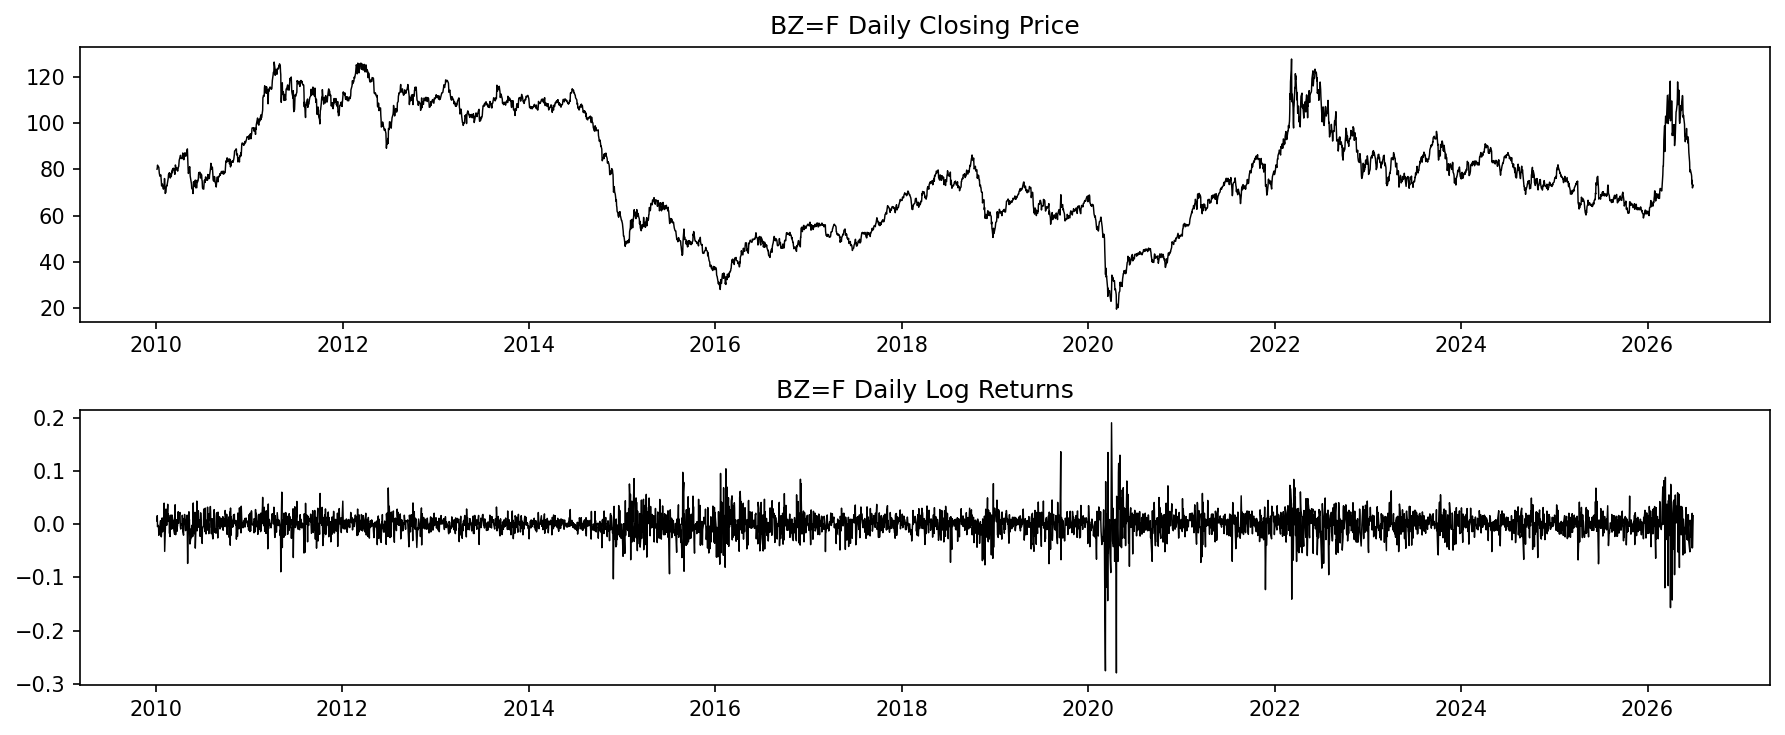

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=150)
axes[0].plot(close, linewidth=0.7, color='black')
axes[0].set_title(f"{TICKER} Daily Closing Price")
axes[1].plot(returns.index.to_timestamp(), returns.values, linewidth=0.7, color='black')
axes[1].set_title(f"{TICKER} Daily Log Returns")
plt.tight_layout()
plt.show()

In [5]:
def get_stats_and_ks(series, name):
    stats = series.describe()
    ks_stat, ks_pval = kstest(series, 'norm', args=(series.mean(), series.std()))
    return {
        'count': stats['count'], 'mean': stats['mean'], 'std': stats['std'],
        'min': stats['min'], 'max': stats['max'],
        'range': stats['max'] - stats['min'],
        'skewness': skew(series), 'kurtosis': kurtosis(series),
        'KS_stat': ks_stat, 'KS_pval': ks_pval, 'Name': name,
    }

stats_df = pd.DataFrame([get_stats_and_ks(returns, "Full Returns")]).set_index('Name')
stats_df

,count,mean,std,min,max,range,skewness,kurtosis,KS_stat,KS_pval
Name,,,,,,,,,,
Full Returns,4114.0,-0.000022,0.023265,-0.279761,0.190774,0.470536,-0.991908,15.168548,0.086489,3.179712e-27


## 3.1 Normality and serial-dependence diagnostics

The KS statistic reported above assumes the observations are **i.i.d.** Daily returns are approximately uncorrelated in the mean (white noise) but *not* independent — they show volatility clustering (strong dependence in squared returns). Under that dependence the i.i.d. KS / Jarque–Bera null distributions are invalid and tend to over-reject. We therefore (Layer 1) document the dependence, (Layer 2) test normality with a dependence-robust test (Bai & Ng 2005, HAC-corrected skewness/kurtosis), and (Layer 3) recompute the KS p-value with a stationary block bootstrap; Anderson–Darling is added for tail sensitivity.

**How to read the dependence tests below.** Each test's H₀ is "no dependence of that kind, up to the tested lag." Rejecting H₀ (p < α) means the data show statistically significant evidence *of* the effect being tested; failing to reject (p > α) means no such evidence was found at that significance level — this does **not** prove the effect is absent, only that this test didn't detect it.

- **Ljung-Box (returns)** — H₀: no autocorrelation in returns (mean is white noise). We *expect* p > α here: if this rejects instead, the mean itself is predictable, which would be a problem for the modelling that follows.
- **Ljung-Box (squared returns)** — H₀: no autocorrelation in squared returns. We *expect* p < α (a rejection) here — this is the volatility-clustering signal that motivates GARCH modelling in the first place.
- **Engle ARCH-LM** — H₀: no ARCH effects (squared returns are not linearly predictable from their own recent lags). Same expectation: p < α confirms ARCH effects are present.


In [6]:
# Layers 1-3 normality / serial-dependence diagnostics (see markdown above).
# Volatility clustering makes the i.i.d. KS test invalid; these address that.
norm_diag = normality_report(returns, name=TICKER, n_boot=N_BOOT, seed=RANDOM_SEED)

# Layer 1 - dependence: mean ~ white noise, variance strongly dependent
# (this is exactly why an i.i.d. distributional test on the levels is invalid).
norm_diag["dependence"].style.format(
    {"statistic": "{:.2f}", "p_value": "{:.2e}"}
).set_caption("Layer 1 - serial dependence: Ljung-Box (returns & squared) + Engle ARCH-LM")

,series,test,lag,statistic,p_value
0,BZ=F,Ljung-Box (returns),10,26.70,2.90e-03
1,BZ=F,Ljung-Box (returns),20,55.72,3.20e-05
2,BZ=F,Ljung-Box (squared returns),10,786.44,1.69e-162
3,BZ=F,Ljung-Box (squared returns),20,1555.62,0.00e+00
4,BZ=F,Engle ARCH-LM,10,434.88,3.50e-87


**How to read the normality tests below.** Every test here shares the same H₀: *the returns are normally distributed.*

- **p < α → reject H₀**: statistically significant evidence *against* normality — the typical, expected finding for daily financial returns (fat tails, occasional skew).
- **p > α → fail to reject H₀**: no evidence against normality was found at this significance level. This does **not** prove normality, only that this particular test could not detect a departure from it.

The **orange** tests (Jarque-Bera, classical KS) assume i.i.d. data — which Layer 1 above shows is violated here — so their p-values are typically **too small** (over-rejection); a rejection there alone is not trustworthy on its own. The **green** tests (Bai-Ng HAC, block-bootstrap KS) stay valid under the dependence just documented, so their p-values are the ones to actually report and interpret.

In [7]:
# Layers 2-3 - normality under dependence. Naive i.i.d. tests (Jarque-Bera,
# classical KS) over-reject; the dependence-robust tests (Bai-Ng HAC joint,
# block-bootstrap KS) plus Anderson-Darling give valid evidence of non-normality.
def _hl_norm(row):
    # Explicit text colour alongside the background: the pastel backgrounds
    # need dark text for contrast, but VS Code's dark theme overrides default
    # text to white, making it unreadable without forcing the colour here.
    a = str(row["assumption"])
    if "robust" in a:
        style = "background-color: #2e7d32; color: #ffffff"   # dependence-robust
    elif "invalid" in a:
        style = "background-color: #bf360c; color: #ffffff"   # i.i.d., invalid here
    else:
        style = ""
    return [style] * len(row)

norm_diag["normality"].style.apply(_hl_norm, axis=1).format(
    {"statistic": "{:.3f}", "p_value": "{:.2e}"}, na_rep="-"
).set_caption("Layers 2-3 - normality: i.i.d. (orange/white text, invalid) vs dependence-robust (green/white text)")

,series,test,assumption,statistic,p_value
0,BZ=F,Jarque-Bera,i.i.d. (invalid here),40114.993,0.00e+00
1,BZ=F,Bai-Ng joint (HAC),dependence-robust,6.953,3.09e-02
2,BZ=F,Bai-Ng skewness (HAC),dependence-robust,-1.549,1.21e-01
3,BZ=F,Bai-Ng kurtosis (HAC),dependence-robust,2.134,3.28e-02
4,BZ=F,KS vs Normal,i.i.d. (invalid here),0.086,3.18e-27
5,BZ=F,KS vs Normal (block-bootstrap),dependence-robust,0.086,5.00e-04
6,BZ=F,Anderson-Darling,i.i.d.; crit@5%=0.752,67.771,-


In [8]:
train_returns = returns[returns.index <= TRAIN_END]
test_returns  = returns[(returns.index >= TEST_START) & (returns.index <= TEST_END)]

print(f"Train: {train_returns.index[0]}  →  {train_returns.index[-1]}  ({len(train_returns)} obs)")
print(f"Test:  {test_returns.index[0]}  →  {test_returns.index[-1]}  ({len(test_returns)} obs)")

Train: 2010-01-05  →  2022-06-30  (3110 obs)
Test:  2022-07-01  →  2026-06-29  (1004 obs)


# 4. Classical Econometric Models (GARCH Family)

Five volatility specifications × three error distributions = 15 models.

| Spec | Description |
|------|-------------|
| GARCH | Standard symmetric GARCH(1,1) — Bollerslev (1986) |
| GJR-GARCH | Asymmetric leverage effect via indicator term — Glosten et al. (1993) |
| EGARCH | Log-variance equation, asymmetric leverage term (`o=ASYM_ORDER`) — Nelson (1991) |
| APARCH | Asymmetric power ARCH, leverage term (`o=ASYM_ORDER`) — Ding et al. (1993) |
| FIGARCH | Fractionally integrated long-memory variance — Baillie et al. (1996) |

## 4.1 In-sample fit

In [9]:
insample_models: dict[str, GARCHModel] = {}
ic_rows = []

for model_type, dist in GARCH_SPECS:
    name  = f"{model_type}-{dist.upper()}"
    model = make_garch(model_type, dist, asym_order=ASYM_ORDER)
    try:
        model.fit(train_returns)
        insample_models[name] = model
        row = model.info_criteria()
        row["Model"] = name
        ic_rows.append(row)
    except Exception as exc:
        print(f"  [WARNING] {name} failed: {exc}")

ic_df = (
    pd.DataFrame(ic_rows)
    .set_index("Model")
    .sort_values("BIC")
    [["LogL", "AIC", "BIC"]]
)
print(f"Fitted {len(insample_models)} / {len(GARCH_SPECS)} models")
ic_df

Fitted 15 / 15 models


,LogL,AIC,BIC
Model,,,
EGARCH-T,-6256.265208,12524.530417,12560.784685
APARCH-T,-6257.658442,12529.316884,12571.613530
GJR-GARCH-T,-6264.173946,12540.347891,12576.602159
GARCH-T,-6269.988512,12549.977024,12580.188914
EGARCH-GED,-6268.587960,12549.175920,12585.430188
FIGARCH-T,-6269.000674,12550.001349,12586.255617
APARCH-GED,-6269.485479,12552.970959,12595.267605
GJR-GARCH-GED,-6276.601527,12565.203054,12601.457322
GARCH-GED,-6283.617069,12577.234138,12607.446028


### 4.1.1 Estimated equations and coefficient significance

The information criteria above say which specification fits better, but not *why* — for that the estimated coefficients and their standard errors are needed. This subsection reports them, and in particular lets us check whether the asymmetry (leverage) coefficient is statistically distinguishable from zero: if it is not, an asymmetric specification is effectively equivalent to its symmetric counterpart, which would explain a better in-sample fit that does not translate into better forecasts.

**Reading the tables.** Coefficients are estimated on returns in **percent** (log-returns × 100), the conventional scaling; slope coefficients (α, β, γ, d, φ, δ) are scale-free, while the intercepts (μ, ω) are on the percent scale. Standard errors are in brackets and stars mark significance (\*\*\* p<0.01, \*\* p<0.05, \* p<0.10). An empty cell means the parameter does not exist in that specification (e.g. `gamma[1]` in a symmetric model, `nu` in a Normal one). A companion table below gives the exact p-value for every coefficient instead of just the stars, for citing precise values.

**H₀ for each coefficient** is that the true value is zero. Rejecting it (small p) means the term contributes; failing to reject means the data cannot distinguish that term's effect from zero — which for γ is exactly the "is the asymmetry parameter redundant?" question.

In [10]:
# Estimated coefficients, publication style: "coef (std_err)" with significance stars.
# Empty cell = parameter not present in that specification.
coef_matrix = param_matrix(insample_models)
print(scale_note(insample_models))
print()
coef_matrix

Coefficients are estimated on returns expressed in percent (log-returns x 100), the conventional scaling in the GARCH literature. Slope coefficients (alpha, beta, gamma, d, phi, delta) are scale-free; the intercepts (mu, omega) are on the percent scale. Standard errors in brackets; *** p<0.01, ** p<0.05, * p<0.10.



parameter,mu,omega,alpha[1],gamma[1],beta[1],phi,d,beta,delta,nu
model,,,,,,,,,,
GARCH-NORMAL,0.0380 (0.0312),0.0864** (0.0361),0.1105*** (0.0280),,0.8788*** (0.0286),,,,,
GARCH-T,0.0694** (0.0272),0.0618*** (0.0202),0.0920*** (0.0143),,0.9010*** (0.0146),,,,,4.6747*** (0.4156)
GARCH-GED,0.0680* (0.0349),0.0681*** (0.0227),0.0953*** (0.0165),,0.8940*** (0.0172),,,,,1.1761*** (0.0482)
GJR-GARCH-NORMAL,0.0043 (0.0299),0.0835*** (0.0321),0.0557*** (0.0186),0.0910*** (0.0312),0.8857*** (0.0251),,,,,
GJR-GARCH-T,0.0582** (0.0272),0.0585*** (0.0189),0.0528*** (0.0143),0.0592*** (0.0179),0.9075*** (0.0146),,,,,4.7953*** (0.4372)
GJR-GARCH-GED,0.0561 (0.0343),0.0647*** (0.0211),0.0530*** (0.0150),0.0659*** (0.0198),0.9006*** (0.0167),,,,,1.1902*** (0.0486)
EGARCH-NORMAL,-0.0164 (0.0314),0.0362*** (0.0102),0.1791*** (0.0334),-0.0730*** (0.0172),0.9814*** (0.0056),,,,,
EGARCH-T,0.0463* (0.0275),0.0255*** (0.0066),0.1527*** (0.0218),-0.0601*** (0.0114),0.9870*** (0.0036),,,,,4.9145*** (0.4550)
EGARCH-GED,0.0465 (0.0328),0.0267*** (0.0071),0.1604*** (0.0241),-0.0617*** (0.0125),0.9852*** (0.0041),,,,,1.2045*** (0.0494)


In [11]:
# Companion table: the exact p-value for every coefficient (not just the
# significance stars above) — useful for citing precise values and for
# borderline cases the *** / ** / * buckets collapse together.
pval_matrix = pvalue_matrix(insample_models, decimals=4)

def _hl_pval(v):
    # same green used for the normality diagnostics, for a consistent and
    # dark-theme-readable "this is significant" signal across the notebook.
    if isinstance(v, (int, float)) and np.isfinite(v) and v < 0.05:
        return "background-color: #2e7d32; color: #ffffff"
    return ""

pval_matrix.style.map(_hl_pval).format(precision=4, na_rep="-").set_caption(
    "Exact p-values per parameter (green = significant at 5%; blank = parameter not in this specification)"
)

parameter,mu,omega,alpha[1],gamma[1],beta[1],phi,d,beta,delta,nu
model,,,,,,,,,,
GARCH-NORMAL,0.2227,0.0167,0.0001,-,0.0000,-,-,-,-,-
GARCH-T,0.0106,0.0022,0.0000,-,0.0000,-,-,-,-,0.0000
GARCH-GED,0.0514,0.0027,0.0000,-,0.0000,-,-,-,-,0.0000
GJR-GARCH-NORMAL,0.8860,0.0092,0.0028,0.0035,0.0000,-,-,-,-,-
GJR-GARCH-T,0.0322,0.0020,0.0002,0.0009,0.0000,-,-,-,-,0.0000
GJR-GARCH-GED,0.1019,0.0021,0.0004,0.0009,0.0000,-,-,-,-,0.0000
EGARCH-NORMAL,0.6014,0.0004,0.0000,0.0000,0.0000,-,-,-,-,-
EGARCH-T,0.0927,0.0001,0.0000,0.0000,0.0000,-,-,-,-,0.0000
EGARCH-GED,0.1556,0.0002,0.0000,0.0000,0.0000,-,-,-,-,0.0000


In [12]:
# Is the asymmetry (leverage) parameter redundant? Direct per-model verdict.
# NOTE: models reported as "no asymmetry parameter estimated" have no gamma in
# their fitted parameter vector, so they are symmetric AS CONFIGURED — worth
# checking against what each specification is intended to capture.
asym_df = asymmetry_summary(insample_models, alpha=0.05)

_n_asym = int(asym_df["has_asymmetry"].sum())
_n_sig = int(asym_df["significant"].sum())
print(f"Models with an estimated asymmetry parameter: {_n_asym} / {len(asym_df)}")
print(f"  of which significant at 5%: {_n_sig}")
print()

asym_df[["has_asymmetry", "coef", "std_err", "t_stat", "p_value", "significant", "verdict"]]

Models with an estimated asymmetry parameter: 9 / 15
  of which significant at 5%: 9



,has_asymmetry,coef,std_err,t_stat,p_value,significant,verdict
GARCH-NORMAL,False,NaN,NaN,NaN,NaN,False,no asymmetry parameter estimated
GARCH-T,False,NaN,NaN,NaN,NaN,False,no asymmetry parameter estimated
GARCH-GED,False,NaN,NaN,NaN,NaN,False,no asymmetry parameter estimated
GJR-GARCH-NORMAL,True,0.091049,0.031226,2.9158,0.003548,True,leverage effect supported
GJR-GARCH-T,True,0.059191,0.017853,3.315519,0.000915,True,leverage effect supported
GJR-GARCH-GED,True,0.065896,0.019826,3.323688,0.000888,True,leverage effect supported
EGARCH-NORMAL,True,-0.072981,0.017199,-4.243283,0.000022,True,leverage effect supported
EGARCH-T,True,-0.060102,0.011355,-5.292952,0.0,True,leverage effect supported
EGARCH-GED,True,-0.061672,0.012463,-4.948265,0.000001,True,leverage effect supported
APARCH-NORMAL,True,0.465658,0.209143,2.226509,0.02598,True,leverage effect supported


In [13]:
# Volatility persistence, using the measure appropriate to each specification
# (alpha+beta for GARCH, alpha+beta+gamma/2 for GJR, beta for EGARCH's log-variance
# AR, and the long-memory parameter d for FIGARCH). Values are comparable only
# within the same measure.
persistence(insample_models)

,measure,value
GARCH-NORMAL,alpha+beta,0.989268
GARCH-T,alpha+beta,0.992948
GARCH-GED,alpha+beta,0.989317
GJR-GARCH-NORMAL,alpha+beta+gamma/2,0.986905
GJR-GARCH-T,alpha+beta+gamma/2,0.989822
GJR-GARCH-GED,alpha+beta+gamma/2,0.986526
EGARCH-NORMAL,beta (log-variance AR),0.981382
EGARCH-T,beta (log-variance AR),0.986958
EGARCH-GED,beta (log-variance AR),0.985242
APARCH-NORMAL,n/a (no closed form),NaN


In [14]:
# Fitted mean and variance equations, with the estimated coefficients substituted.
# The variance equation shown reflects the specification AS ESTIMATED — an
# asymmetry term appears only where an asymmetry coefficient was actually fitted.
from IPython.display import Markdown, display

display(Markdown(equations_markdown(insample_models, decimals=4)))

$$\begin{aligned} \textbf{GARCH-NORMAL} \\[2pt] r_t = 0.0380 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^2 = 0.0864 + 0.1105\,\varepsilon_{t-1}^2 + 0.8788\,\sigma_{t-1}^2 \end{aligned}$$

$$\begin{aligned} \textbf{GARCH-T} \\[2pt] r_t = 0.0694 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^2 = 0.0618 + 0.0920\,\varepsilon_{t-1}^2 + 0.9010\,\sigma_{t-1}^2 \\[2pt] \nu = 4.6747 \end{aligned}$$

$$\begin{aligned} \textbf{GARCH-GED} \\[2pt] r_t = 0.0680 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^2 = 0.0681 + 0.0953\,\varepsilon_{t-1}^2 + 0.8940\,\sigma_{t-1}^2 \\[2pt] \nu = 1.1761 \end{aligned}$$

$$\begin{aligned} \textbf{GJR-GARCH-NORMAL} \\[2pt] r_t = 0.0043 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^2 = 0.0835 + 0.0557\,\varepsilon_{t-1}^2 + 0.0910\,\varepsilon_{t-1}^2\,\mathbb{1}_{\{\varepsilon_{t-1} < 0\}} + 0.8857\,\sigma_{t-1}^2 \end{aligned}$$

$$\begin{aligned} \textbf{GJR-GARCH-T} \\[2pt] r_t = 0.0582 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^2 = 0.0585 + 0.0528\,\varepsilon_{t-1}^2 + 0.0592\,\varepsilon_{t-1}^2\,\mathbb{1}_{\{\varepsilon_{t-1} < 0\}} + 0.9075\,\sigma_{t-1}^2 \\[2pt] \nu = 4.7953 \end{aligned}$$

$$\begin{aligned} \textbf{GJR-GARCH-GED} \\[2pt] r_t = 0.0561 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^2 = 0.0647 + 0.0530\,\varepsilon_{t-1}^2 + 0.0659\,\varepsilon_{t-1}^2\,\mathbb{1}_{\{\varepsilon_{t-1} < 0\}} + 0.9006\,\sigma_{t-1}^2 \\[2pt] \nu = 1.1902 \end{aligned}$$

$$\begin{aligned} \textbf{EGARCH-NORMAL} \\[2pt] r_t = -0.0164 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \ln \sigma_t^2 = 0.0362 + 0.1791\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) - 0.0730\,z_{t-1} + 0.9814\,\ln \sigma_{t-1}^2 \end{aligned}$$

$$\begin{aligned} \textbf{EGARCH-T} \\[2pt] r_t = 0.0463 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \ln \sigma_t^2 = 0.0255 + 0.1527\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) - 0.0601\,z_{t-1} + 0.9870\,\ln \sigma_{t-1}^2 \\[2pt] \nu = 4.9145 \end{aligned}$$

$$\begin{aligned} \textbf{EGARCH-GED} \\[2pt] r_t = 0.0465 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \ln \sigma_t^2 = 0.0267 + 0.1604\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) - 0.0617\,z_{t-1} + 0.9852\,\ln \sigma_{t-1}^2 \\[2pt] \nu = 1.2045 \end{aligned}$$

$$\begin{aligned} \textbf{APARCH-NORMAL} \\[2pt] r_t = -0.0130 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^{1.0106} = 0.0526 + 0.0987\,\left(|\varepsilon_{t-1}| - 0.4657\,\varepsilon_{t-1}\right)^{1.0106} + 0.9013\,\sigma_{t-1}^{1.0106} \end{aligned}$$

$$\begin{aligned} \textbf{APARCH-T} \\[2pt] r_t = 0.0520 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^{1.2206} = 0.0405 + 0.0821\,\left(|\varepsilon_{t-1}| - 0.3932\,\varepsilon_{t-1}\right)^{1.2206} + 0.9179\,\sigma_{t-1}^{1.2206} \\[2pt] \nu = 5.0631 \end{aligned}$$

$$\begin{aligned} \textbf{APARCH-GED} \\[2pt] r_t = 0.0513 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^{1.1685} = 0.0429 + 0.0877\,\left(|\varepsilon_{t-1}| - 0.3971\,\varepsilon_{t-1}\right)^{1.1685} + 0.9123\,\sigma_{t-1}^{1.1685} \\[2pt] \nu = 1.2081 \end{aligned}$$

$$\begin{aligned} \textbf{FIGARCH-NORMAL} \\[2pt] r_t = 0.0351 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^2 = 0.1836 + 0.5860\,\sigma_{t-1}^2 + \left[1 - 0.5860L - (1 - 0.2534L)(1-L)^{0.4931}\right]\varepsilon_t^2 \end{aligned}$$

$$\begin{aligned} \textbf{FIGARCH-T} \\[2pt] r_t = 0.0666 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^2 = 0.1505 + 0.6243\,\sigma_{t-1}^2 + \left[1 - 0.6243L - (1 - 0.2471L)(1-L)^{0.5058}\right]\varepsilon_t^2 \\[2pt] \nu = 4.6519 \end{aligned}$$

$$\begin{aligned} \textbf{FIGARCH-GED} \\[2pt] r_t = 0.0645 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^2 = 0.1450 + 0.5973\,\sigma_{t-1}^2 + \left[1 - 0.5973L - (1 - 0.2624L)(1-L)^{0.4753}\right]\varepsilon_t^2 \\[2pt] \nu = 1.1722 \end{aligned}$$

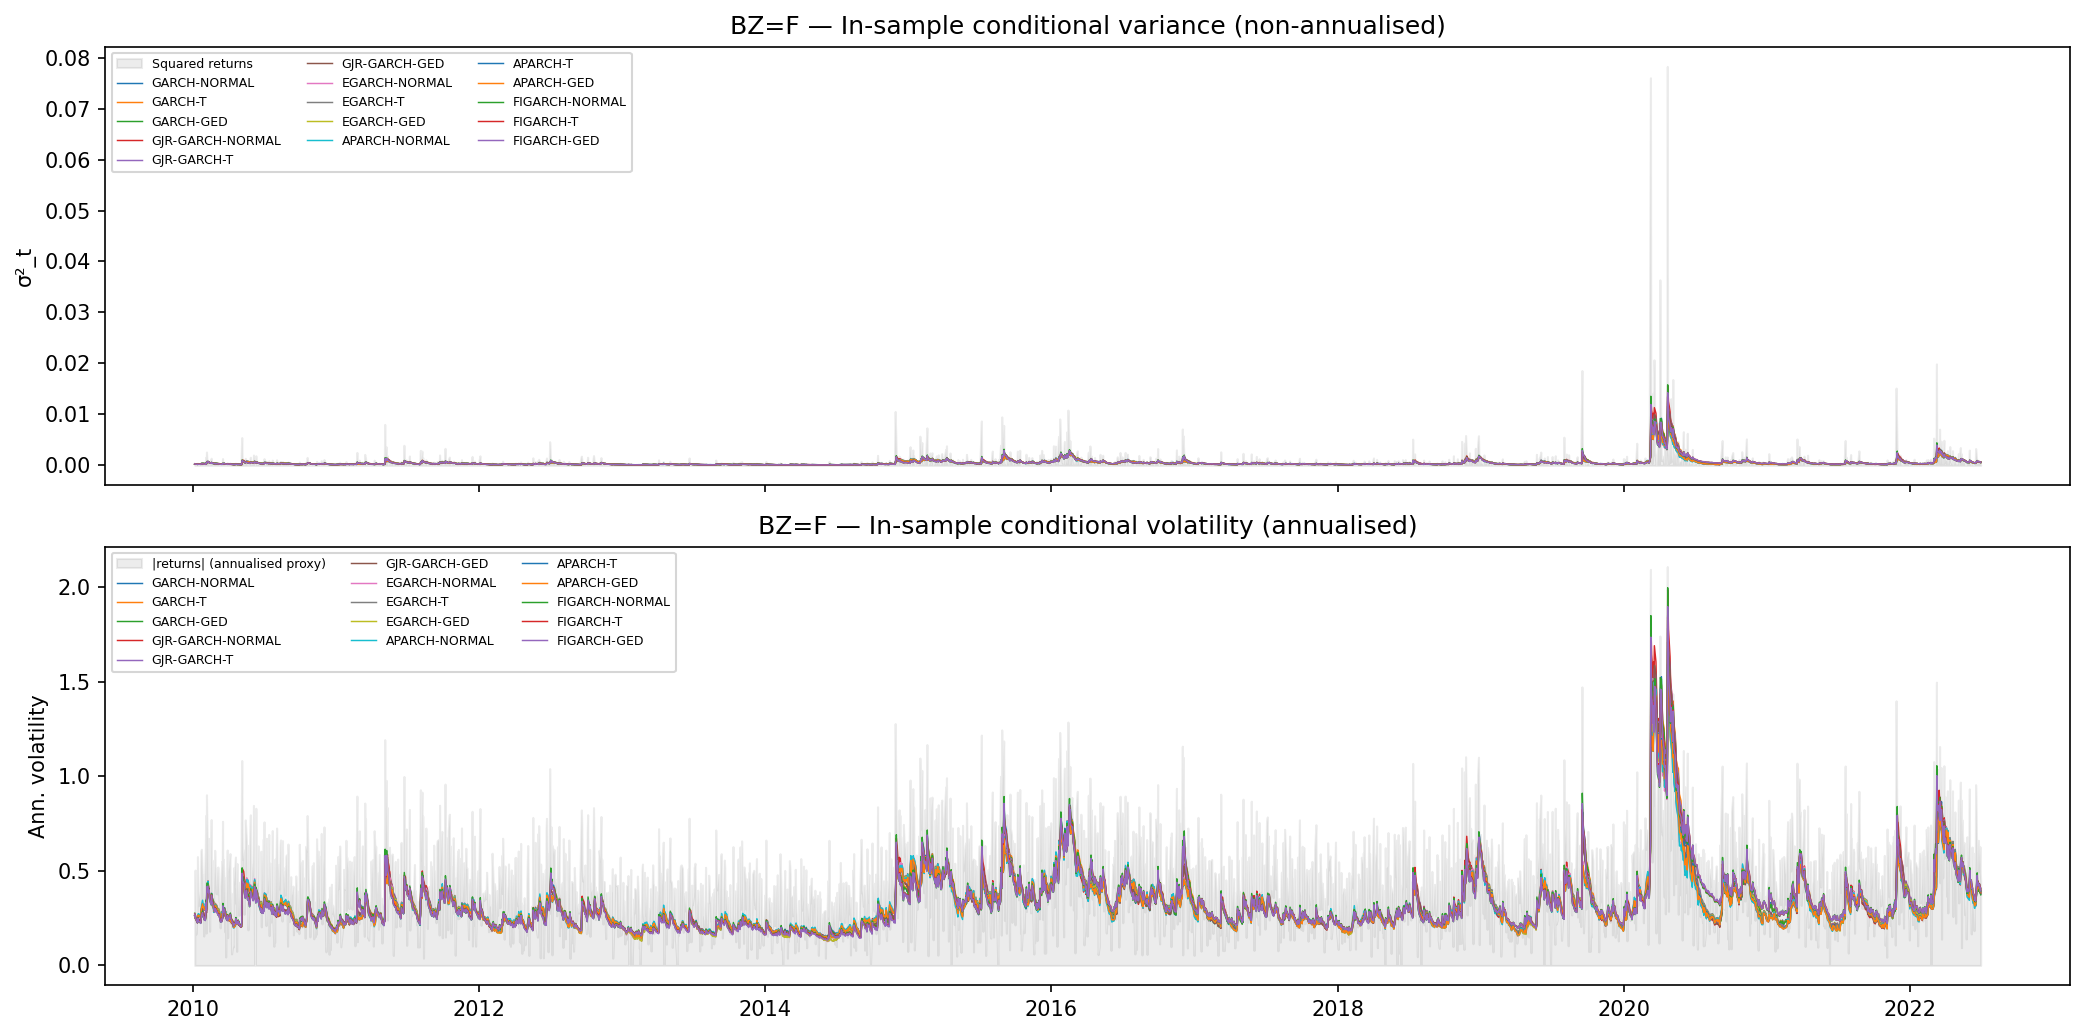

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), dpi=150, sharex=True)

# Raw variance
axes[0].fill_between(
    train_returns.index.to_timestamp(),
    train_returns.values ** 2,
    alpha=0.15, color="gray", label="Squared returns",
)
for name, model in insample_models.items():
    cv = model.insample_variance()
    axes[0].plot(cv.index.to_timestamp(), cv.values, linewidth=0.7, label=name)
axes[0].set_title(f"{TICKER} — In-sample conditional variance (non-annualised)")
axes[0].set_ylabel("σ²_t")
axes[0].legend(fontsize=6, ncol=3)

# Annualised volatility
axes[1].fill_between(
    train_returns.index.to_timestamp(),
    np.sqrt(np.abs(train_returns.values) * np.sqrt(252)),
    alpha=0.15, color="gray", label="|returns| (annualised proxy)",
)
for name, model in insample_models.items():
    cv = model.insample_variance()
    axes[1].plot(cv.index.to_timestamp(), np.sqrt(cv.values * 252), linewidth=0.7, label=name)
axes[1].set_title(f"{TICKER} — In-sample conditional volatility (annualised)")
axes[1].set_ylabel("Ann. volatility")
axes[1].legend(fontsize=6, ncol=3)

plt.tight_layout()
plt.show()

### 4.1.2 Distributional diagnostics on the standardized residuals

Section 3.1 tested the **returns** for normality. That describes the *unconditional* distribution, and on its own it cannot justify the choice of innovation distribution made here: with $r_t = \sqrt{h_t}\,z_t$, a time-varying $h_t$ makes the returns fat-tailed **even when every $z_t$ is exactly Gaussian**. Rejecting normality on the returns is therefore the expected outcome under *any* GARCH model, and carries no information about whether Normal, Student-$t$ or GED innovations are needed.

The assumption each specification actually makes is about the standardized residuals $z_t = (r_t - \hat\mu)/\sqrt{h_t}$. This subsection tests those, and asks two questions that should not be conflated.

**(a) Is the variance equation adequate?** `LB2(20) p` and `ARCH-LM p` re-run the Layer-1 dependence tests on $z_t$. The expectation is the **opposite** of Section 3.1: a well-specified $h_t$ should have absorbed the clustering, so **large p-values are the good outcome here**. A rejection means the variance equation is misspecified, and nothing in the distributional columns can be read safely below it.

**(b) Which innovation distribution is warranted?** Two different nulls, and the distinction matters:

- `BaiNg p`, `KS-N p`, `AD-N` test $z_t$ against a **Normal** null — dependence-robust Bai–Ng, block-bootstrap KS, and Anderson–Darling. Small p ⇒ the Normal innovation assumption is rejected. The null is identical for all fifteen models, so these columns are directly comparable across the table.
- `PIT KS p`, `PIT AD` test each model against **its own** fitted distribution, through the probability integral transform $u_t = F(z_t;\hat\theta)$ (Diebold, Günther & Tay 1998). Under correct specification of both the variance equation and the innovation distribution, $u_t \sim$ i.i.d. $U(0,1)$, so **large p is the good outcome**. This is the only column that puts Normal, $t$ and GED specifications on a common footing, because each is judged against the distribution it was actually estimated under.

`AD-N` and `PIT AD` are Anderson–Darling statistics rather than p-values. They weight the **tails**, which is exactly where the choice between Normal, $t$ and GED is decided, whereas KS is most sensitive near the median and can miss it. For the PIT, reject at 5% when `PIT AD` > 2.492 — a deliberately conservative threshold, since it ignores that $\hat\theta$ was estimated.

`nu` is the fitted shape parameter (degrees of freedom for $t$, the power parameter for GED); blank for Normal, which has none.

In [16]:
# Layer 4 - the distributional tests applied where the assumption actually lives:
# the standardized residuals of each fitted model, plus a probability-integral
# transform under each model's OWN innovation distribution.
# Runtime note: two block bootstraps per model, so this is the slowest cell in
# section 4.1 (~1 min for 15 models at N_BOOT=2000).
ALPHA_DIST = 0.05  # significance level for the distributional verdicts below

resid_diag = residual_diagnostics_table(
    insample_models, lb_lag=20, n_boot=N_BOOT, seed=RANDOM_SEED
)

def _hl_resid(col):
    # Explicit text colour alongside the background: VS Code's dark theme
    # overrides default text to white, which is unreadable on pastel fills.
    ok, bad = "background-color: #2e7d32; color: #ffffff", "background-color: #bf360c; color: #ffffff"
    if col.name in ("LB2(20) p", "ARCH-LM p"):
        # adequacy of the variance equation: LARGE p is the good outcome
        return [ok if v > ALPHA_DIST else bad for v in col]
    if col.name in ("BaiNg p", "KS-N p"):
        # normality of z_t: a rejection is evidence AGAINST Normal innovations
        return [bad if v < ALPHA_DIST else ok for v in col]
    if col.name == "PIT KS p":
        # adequacy of each model's OWN distribution: LARGE p is the good outcome
        return [ok if v > ALPHA_DIST else bad for v in col]
    if col.name == "PIT AD":
        return [ok if v <= 2.492 else bad for v in col]
    return [""] * len(col)

print(f"Standardized residuals of {len(insample_models)} models fitted on the training window")
print(f"green = the model's assumption survives this test; orange = it is rejected (alpha={ALPHA_DIST})")
print()
resid_diag.style.apply(_hl_resid, axis=0).format(
    {"nu": "{:.3f}", "LB2(20) p": "{:.3f}", "ARCH-LM p": "{:.3f}",
     "skew": "{:+.3f}", "ex.kurt": "{:.3f}", "BaiNg p": "{:.2e}",
     "KS-N p": "{:.3f}", "AD-N": "{:.2f}", "PIT KS p": "{:.3f}", "PIT AD": "{:.3f}"},
    na_rep="-",
).set_caption("Layer 4 - residual diagnostics: variance-equation adequacy, normality of z_t, and PIT under each model's own distribution")

Standardized residuals of 15 models fitted on the training window
green = the model's assumption survives this test; orange = it is rejected (alpha=0.05)



,dist,nu,n,LB2(20) p,ARCH-LM p,skew,ex.kurt,BaiNg p,KS-N p,AD-N,PIT KS p,PIT AD
model,,,,,,,,,,,,
GARCH-NORMAL,normal,-,3110,0.964,0.793,-0.677,4.447,3.37e-05,0.000,19.17,0.000,17.872
GARCH-T,t,4.675,3110,0.939,0.676,-0.699,4.576,4.70e-05,0.000,19.21,0.407,1.888
GARCH-GED,ged,1.176,3110,0.951,0.728,-0.690,4.521,4.05e-05,0.000,19.13,0.264,2.172
GJR-GARCH-NORMAL,normal,-,3110,0.986,0.875,-0.633,4.051,1.24e-05,0.000,17.90,0.000,17.350
GJR-GARCH-T,t,4.795,3110,0.976,0.813,-0.660,4.224,1.52e-05,0.000,18.11,0.438,1.714
GJR-GARCH-GED,ged,1.190,3110,0.981,0.849,-0.650,4.156,1.35e-05,0.000,17.99,0.348,1.995
EGARCH-NORMAL,normal,-,3110,0.975,0.760,-0.628,3.819,8.04e-06,0.000,17.11,0.000,17.454
EGARCH-T,t,4.915,3110,0.937,0.560,-0.654,3.997,1.60e-05,0.000,17.36,0.197,1.856
EGARCH-GED,ged,1.205,3110,0.958,0.653,-0.645,3.929,1.27e-05,0.000,17.25,0.278,2.217


**Detailed battery for the best-fitting specification.** The table above compresses each test to a single number; the three tables below show the full battery for the model that information criteria select, so the individual statistics can be cited.

The `adequacy` table is the variance-equation check — here a **large** p-value is the good outcome. The `normality` table asks whether the Normal innovation assumption holds for $z_t$; as in Section 3.1, the dependence-robust rows (Bai–Ng HAC, block-bootstrap KS) are the ones to report, though after GARCH filtering the i.i.d. rows are far less objectionable than they were on raw returns, since most of the dependence has been removed. The `pit` table asks whether this model's **own** fitted distribution is adequate.

Note on resolution: the block-bootstrap p-value cannot fall below $1/(B+1)$, so a reported value equal to that floor means "smaller than this bootstrap can resolve", not exactly that number.

In [17]:
# Full battery for the specification selected by BIC.
best_ic_name  = ic_df.index[0]
best_ic_model = insample_models[best_ic_name]

resid_rep = residual_report(
    best_ic_model.std_resid,
    name=best_ic_name,
    pit=best_ic_model.pit(),
    dist_label=best_ic_model.dist,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)

shape = best_ic_model.dist_params
print(f"Best by BIC: {best_ic_name}"
      + (f"   ({', '.join(f'{k}={v:.3f}' for k, v in shape.items())})" if shape else ""))
print(f"Bootstrap p-value floor: {1 / (N_BOOT + 1):.2e}")
for key, title in [("adequacy",  "variance equation - large p is GOOD (no ARCH left in z_t)"),
                   ("normality", "is the NORMAL assumption adequate for z_t?"),
                   ("pit",       "is this model's OWN fitted distribution adequate? large p is GOOD")]:
    print(f"\n--- {key}: {title} ---")
    print(resid_rep[key].to_string(index=False))

Best by BIC: EGARCH-T   (nu=4.915)
Bootstrap p-value floor: 5.00e-04

--- adequacy: variance equation - large p is GOOD (no ARCH left in z_t) ---
   model                               test  lag  statistic  p_value
EGARCH-T         Ljung-Box (std. residuals)   10   6.345808 0.785422
EGARCH-T         Ljung-Box (std. residuals)   20  14.478320 0.805440
EGARCH-T Ljung-Box (squared std. residuals)   10   8.846133 0.546766
EGARCH-T Ljung-Box (squared std. residuals)   20  11.320229 0.937491
EGARCH-T                      Engle ARCH-LM   10   8.704324 0.560375

--- normality: is the NORMAL assumption adequate for z_t? ---
   model                           test            assumption   statistic      p_value
EGARCH-T                    Jarque-Bera                i.i.d. 2291.708367 0.000000e+00
EGARCH-T             Bai-Ng joint (HAC)     dependence-robust   22.087721 1.598499e-05
EGARCH-T          Bai-Ng skewness (HAC)     dependence-robust   -3.199380 1.377235e-03
EGARCH-T          Bai-Ng kurt

## 4.2 Out-of-sample evaluation

Window scheme controlled by `WINDOW_TYPE` (expanding or sliding), 1-step-ahead.  
Parameters re-estimated every `REFIT_EVERY` steps.  
Realized variance proxy controlled by `VARIANCE_PROXY` (default: Garman-Klass).

In [18]:
evaluator = RollingEvaluator(
    n_ahead=N_AHEAD, refit_every=REFIT_EVERY,
    window_type=WINDOW_TYPE, window_size=WINDOW_SIZE,
)

# functools.partial is picklable — required when PARALLEL_JOBS != 1.
# lambda would work for sequential (n_jobs=1) but cannot be sent to worker processes.
garch_eval_specs = [
    (partial(make_garch, t, d, asym_order=ASYM_ORDER), f"{t}-{d.upper()}")
    for t, d in GARCH_SPECS
]

garch_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    garch_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    # train_target_series deliberately not passed: GARCH is estimated
    # by QMLE on returns and has no regression target to redirect.
    verbose=True, n_jobs=PARALLEL_JOBS,
)
_width = WINDOW_SIZE if (WINDOW_TYPE == "sliding" and WINDOW_SIZE is not None) else (
    len(train_returns) if WINDOW_TYPE == "sliding" else "n/a"
)
print(f"\nCompleted {len(garch_results)} GARCH models.")
print(f"Window type: {WINDOW_TYPE}  |  Window size: {_width}  |  Proxy: {VARIANCE_PROXY}")

Parallel evaluation: 15 models on 10 worker process(es)...
  [GARCH-NORMAL] done  RMSE=2.3065e-03
  [GJR-GARCH-NORMAL] done  RMSE=2.3341e-03
  [GARCH-GED] done  RMSE=2.3112e-03
  [GARCH-T] done  RMSE=2.3121e-03
  [EGARCH-NORMAL] done  RMSE=2.3460e-03
  [GJR-GARCH-T] done  RMSE=2.3353e-03
  [EGARCH-T] done  RMSE=2.3506e-03
  [GJR-GARCH-GED] done  RMSE=2.3343e-03
  [EGARCH-GED] done  RMSE=2.3486e-03
  [APARCH-NORMAL] done  RMSE=2.3467e-03
  [APARCH-T] done  RMSE=2.3508e-03
  [APARCH-GED] done  RMSE=2.3484e-03
  [FIGARCH-NORMAL] done  RMSE=2.3036e-03
  [FIGARCH-T] done  RMSE=2.3101e-03
  [FIGARCH-GED] done  RMSE=2.3085e-03

Completed 15 GARCH models.
Window type: expanding  |  Window size: n/a  |  Proxy: garman_klass_overnight


In [19]:
garch_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in garch_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
garch_metrics_df

,RMSE,MAE,MSE,QLIKE
FIGARCH-NORMAL,0.002304,0.000461,0.000005,-6.662696
GARCH-NORMAL,0.002306,0.000463,0.000005,-6.654321
FIGARCH-GED,0.002309,0.000457,0.000005,-6.656476
FIGARCH-T,0.002310,0.000458,0.000005,-6.654244
GARCH-GED,0.002311,0.000459,0.000005,-6.646201
GARCH-T,0.002312,0.000464,0.000005,-6.645537
GJR-GARCH-NORMAL,0.002334,0.000476,0.000005,-6.605694
GJR-GARCH-GED,0.002334,0.000470,0.000005,-6.599813
GJR-GARCH-T,0.002335,0.000474,0.000005,-6.599344
EGARCH-NORMAL,0.002346,0.000472,0.000006,-6.543487


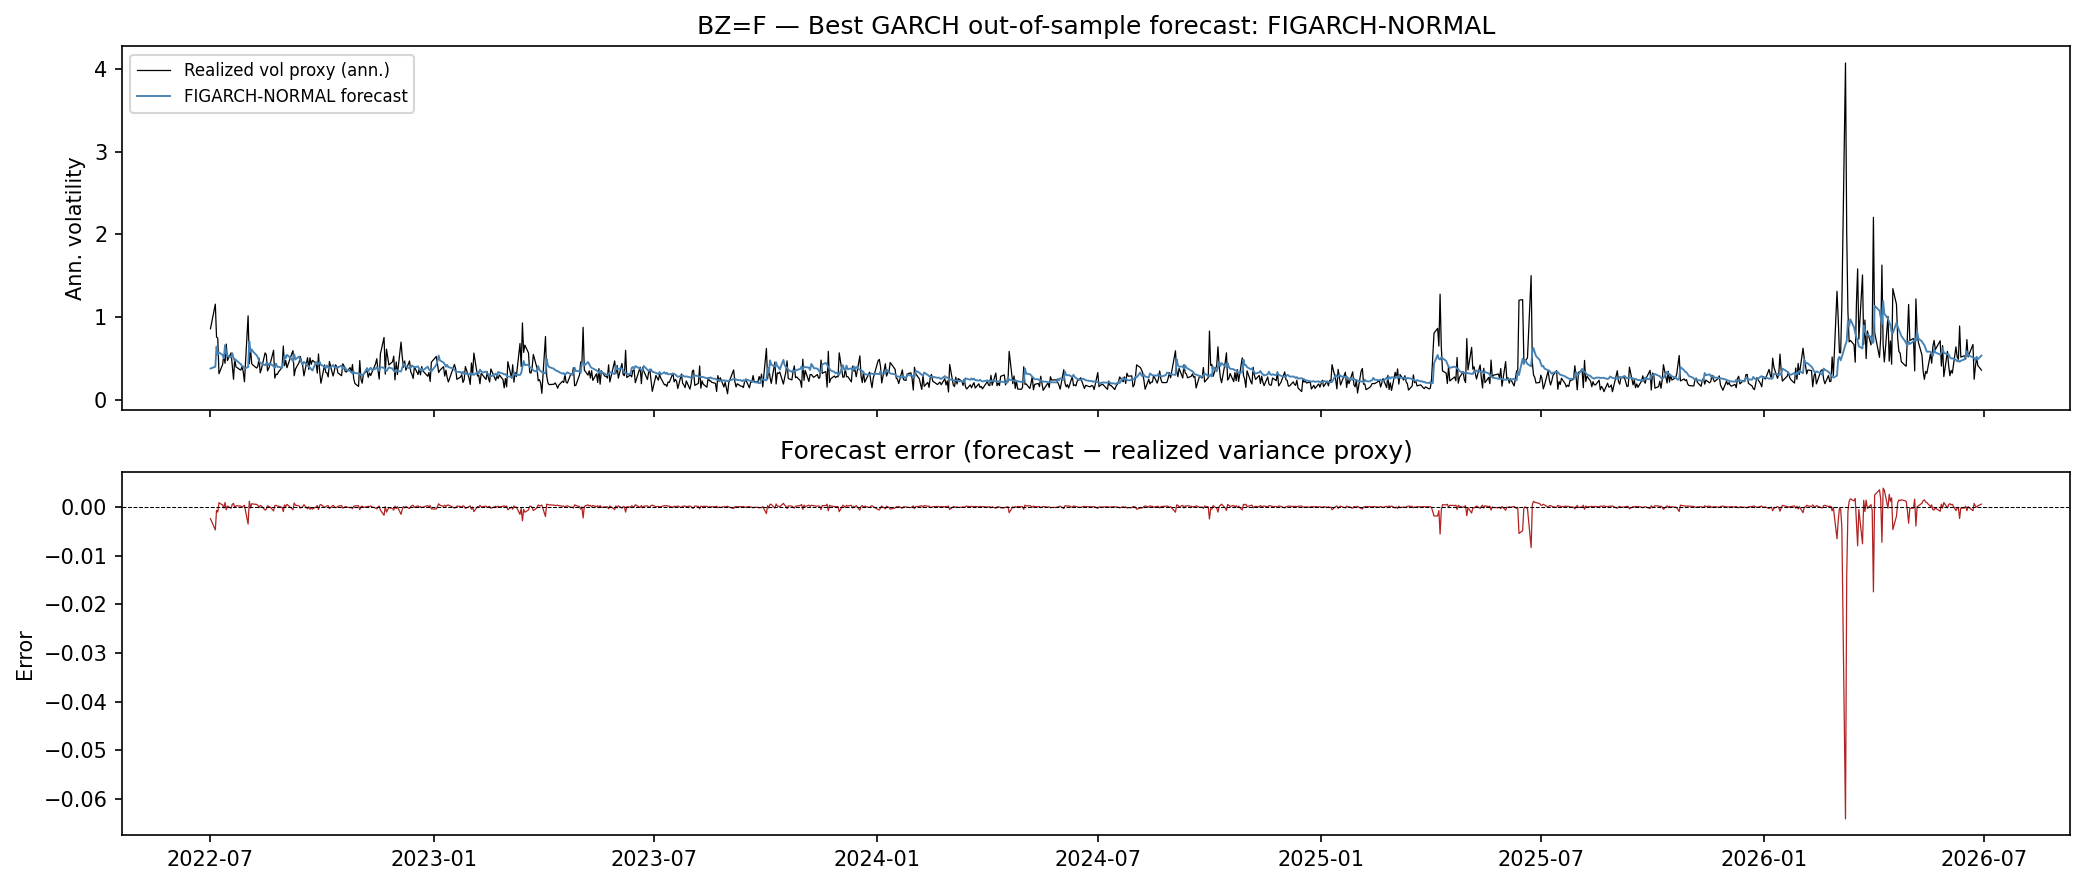

In [20]:
best_garch_name = garch_metrics_df.index[0]
r = garch_results[best_garch_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)
axes[0].plot(r.actuals.index.to_timestamp(), np.sqrt(r.actuals.values * 252),
             color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
axes[0].plot(r.forecasts.index.to_timestamp(), np.sqrt(r.forecasts.values * 252),
             color='steelblue', linewidth=0.9, label=f'{best_garch_name} forecast')
axes[0].set_title(f"{TICKER} — Best GARCH out-of-sample forecast: {best_garch_name}")
axes[0].set_ylabel("Ann. volatility")
axes[0].legend(fontsize=8)
axes[1].plot(r.errors.index.to_timestamp(), r.errors.values, color='firebrick', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title("Forecast error (forecast − realized variance proxy)")
axes[1].set_ylabel("Error")
plt.tight_layout()
plt.show()

## 4.3 Realized GARCH (Hansen, Huang & Shek 2012)

Every specification in 4.1–4.2 is estimated by QMLE on close-to-close returns, so the only thing it ever learns about day $t$ is $r_t$. The ML models in the sections below are trained on a range-based proxy and therefore also see the daily high–low range. That is what makes "ML beats GARCH" ambiguous as a claim: part of any gap is the **model class** and part is simply the richer **information set**, and a comparison between the two groups as they stand cannot separate them.

Realized GARCH closes that gap from the other side — a GARCH model that also observes the realized measure $x_t$:

$$\log h_t = \omega + \beta \log h_{t-1} + \gamma \log x_{t-1}$$
$$\log x_t = \xi + \varphi \log h_t + \tau(z_t) + u_t, \qquad \tau(z) = \tau_1 z + \tau_2(z^2-1)$$

The **measurement equation** is what makes this more than a GARCH with an extra regressor: it states explicitly how the noisy observable $x_t$ relates to the latent $h_t$, which is what allows both equations to be estimated jointly rather than plugging $x_t$ in as though it were exact. Persistence is $\beta + \varphi\gamma$, not $\beta$.

**Which realized measure.** Any per-day proxy, set by `REALIZED_GARCH_SPECS`; each choice is a different model and gets its own row. Yang–Zhang cannot serve — it is a multi-day estimator, so a rolling YZ at date $t$ is the average variance over the preceding window rather than day $t$'s variance. $\varphi$ would absorb the smoothing, $u_t$ would be heavily autocorrelated in violation of its own assumption, and the premise that $x_t$ is a sharper signal of $h_t$ than $r_t^2$ would be lost.

**Reading the likelihood.** The *joint* likelihood scores both equations, so it is **not** comparable with the return-only likelihood of a plain GARCH — it is evaluating a different number of observed series. The table below reports the **partial** (return-equation) likelihood, which is comparable, and still charges all eight parameters against it; that is the conservative direction, and it cannot flatter this model relative to section 4.1. Returns are scaled by 100 exactly as in 4.1 — without that the two sets of log-likelihoods would differ by about $n\log 100 \approx 14{,}300$ for purely dimensional reasons.

In [21]:
# In-sample fit, one model per realized measure. Kept in its own dict rather
# than merged into `insample_models`: that dict feeds param_matrix() and the
# residual diagnostics in 4.1.x, neither of which applies to this model.
realized_models: dict[str, RealizedGARCH] = {}
rg_rows = []

for _rm in REALIZED_GARCH_SPECS:
    _name = f"RealGARCH-{_rm}"
    try:
        _m = RealizedGARCH(realized_measures[_rm]).fit(train_returns)
        realized_models[_name] = _m
        _p, _ic = _m.params, _m.info_criteria()
        rg_rows.append({
            "Model": _name, "beta": _p["beta"], "gamma": _p["gamma"],
            "phi": _p["phi"], "xi": _p["xi"], "tau1": _p["tau1"],
            "tau2": _p["tau2"], "sigma_u": _p["sigma_u"],
            "persistence": _m.persistence,
            "LogL": _ic["LogL"], "BIC": _ic["BIC"], "LogL_joint": _ic["LogL_joint"],
        })
    except Exception as exc:
        print(f"  [WARNING] {_name} failed: {exc}")

if rg_rows:
    rg_df = pd.DataFrame(rg_rows).set_index("Model")
    _best_garch_bic = ic_df["BIC"].min()
    print(f"Best GARCH BIC (section 4.1): {_best_garch_bic:.1f}   "
          f"[{ic_df['BIC'].idxmin()}]")
    print("LogL/BIC below are PARTIAL (return equation only), so they sit on the")
    print("same footing as section 4.1; LogL_joint additionally scores the")
    print("measurement equation and is NOT comparable with it.")
    display(rg_df.round(4))
else:
    print("No Realized GARCH models fitted (REALIZED_GARCH_SPECS is empty).")

Best GARCH BIC (section 4.1): 12560.8   [EGARCH-T]
LogL/BIC below are PARTIAL (return equation only), so they sit on the
same footing as section 4.1; LogL_joint additionally scores the
measurement equation and is NOT comparable with it.


,beta,gamma,phi,xi,tau1,tau2,sigma_u,persistence,LogL,BIC,LogL_joint
Model,,,,,,,,,,,
RealGARCH-garman_klass,0.8982,0.0749,1.2318,-1.1907,-0.0541,0.1349,1.3454,0.9904,-6467.4640,12999.2671,-11802.9949
RealGARCH-garman_klass_overnight,0.8910,0.0976,0.9959,-0.5861,-0.0336,0.1763,1.2788,0.9882,-6421.2356,12906.8102,-11599.0734
RealGARCH-rogers_satchell_overnight,0.9030,0.0865,1.0020,-0.6329,-0.0639,0.1334,1.3403,0.9896,-6423.9896,12912.3181,-11747.8655


In [22]:
# Out-of-sample, through the same evaluator as every other model group.
# The realized measure travels with the factory, not through the evaluator:
# it defines WHICH model this is, so train_target_series is deliberately not
# passed here — the notebook's ML training target must not redefine it.
realized_eval_specs = [
    (partial(make_realized_garch, realized_measures[_rm]), f"RealGARCH-{_rm}")
    for _rm in REALIZED_GARCH_SPECS
]

realized_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    realized_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    verbose=True, n_jobs=PARALLEL_JOBS,
) if realized_eval_specs else {}

if realized_results:
    _rg_metrics = (
        pd.DataFrame({n: r.metrics() for n, r in realized_results.items()})
        .T[["RMSE", "MAE", "MSE", "QLIKE"]]
        .sort_values("QLIKE")
    )
    _best_garch = min(garch_results, key=lambda n: garch_results[n].metrics()["QLIKE"])
    _bg = garch_results[_best_garch].metrics()
    print(f"\nBest plain GARCH out-of-sample: {_best_garch}  "
          f"QLIKE={_bg['QLIKE']:.6f}  RMSE={_bg['RMSE']:.6e}")
    print("A Realized GARCH beating it isolates the value of the RANGE information")
    print("inside one model class — the same information the ML models are trained on.")
    display(_rg_metrics)

Parallel evaluation: 3 models on 10 worker process(es)...
  [RealGARCH-garman_klass_overnight] done  RMSE=2.3043e-03
  [RealGARCH-garman_klass] done  RMSE=2.3223e-03
  [RealGARCH-rogers_satchell_overnight] done  RMSE=2.3102e-03

Best plain GARCH out-of-sample: FIGARCH-NORMAL  QLIKE=-6.662696  RMSE=2.303624e-03
A Realized GARCH beating it isolates the value of the RANGE information
inside one model class — the same information the ML models are trained on.


,RMSE,MAE,MSE,QLIKE
RealGARCH-garman_klass_overnight,0.002304,0.000503,0.000005,-6.638990
RealGARCH-rogers_satchell_overnight,0.002310,0.000505,0.000005,-6.629458
RealGARCH-garman_klass,0.002322,0.000509,0.000005,-6.599518


# 5. Standalone XGBoost

XGBoost regressor trained directly on lagged squared returns (realized variance proxies) and, optionally, lagged raw returns.  
No distributional assumptions — the model learns the mapping from lagged features to next-step variance.  
Hyperparameters are tuned via Optuna according to `XGB_TUNE` in the config (`"first"` by default: one search at the first estimation, held fixed for the whole rolling evaluation). The importances below are from a single untuned fit on the training window, which is about which features the model leans on, not about the tuned configuration.

## 5.1 Out-of-sample evaluation

In [23]:
xgb_eval_specs = [
    (
        tuned_factory(XGBVolatilityModel, tune=XGB_TUNE,
                n_lags=XGB_N_LAGS,
                use_returns=XGB_USE_RETURNS,
                n_trials=XGB_N_TRIALS,
                optuna_n_jobs=XGB_OPTUNA_JOBS,
                xgb_params=XGB_PARAMS),
        "XGB-Standalone",
    )
]

xgb_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    xgb_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    train_target_series=ml_train_target,
    verbose=True, n_jobs=1,   # single model — no benefit from spawning a process
)
print(f"\nCompleted {len(xgb_results)} standalone XGB model(s).")

Evaluating XGB-Standalone...


/opt/anaconda3/envs/volatility-pipeline-new/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [XGB-Standalone] re-fitted at step 0/1004 (expanding)
  [XGB-Standalone] re-fitted at step 10/1004 (expanding)
  [XGB-Standalone] re-fitted at step 20/1004 (expanding)
  [XGB-Standalone] re-fitted at step 30/1004 (expanding)
  [XGB-Standalone] re-fitted at step 40/1004 (expanding)
  [XGB-Standalone] re-fitted at step 50/1004 (expanding)
  [XGB-Standalone] re-fitted at step 60/1004 (expanding)
  [XGB-Standalone] re-fitted at step 70/1004 (expanding)
  [XGB-Standalone] re-fitted at step 80/1004 (expanding)
  [XGB-Standalone] re-fitted at step 90/1004 (expanding)
  [XGB-Standalone] re-fitted at step 100/1004 (expanding)
  [XGB-Standalone] re-fitted at step 110/1004 (expanding)
  [XGB-Standalone] re-fitted at step 120/1004 (expanding)
  [XGB-Standalone] re-fitted at step 130/1004 (expanding)
  [XGB-Standalone] re-fitted at step 140/1004 (expanding)
  [XGB-Standalone] re-fitted at step 150/1004 (expanding)
  [XGB-Standalone] re-fitted at step 160/1004 (expanding)
  [XGB-Standalone] re-fit

In [24]:
xgb_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in xgb_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
xgb_metrics_df

,RMSE,MAE,MSE,QLIKE
XGB-Standalone,0.002338,0.000465,0.000005,-6.554302


## 5.2 Feature importance

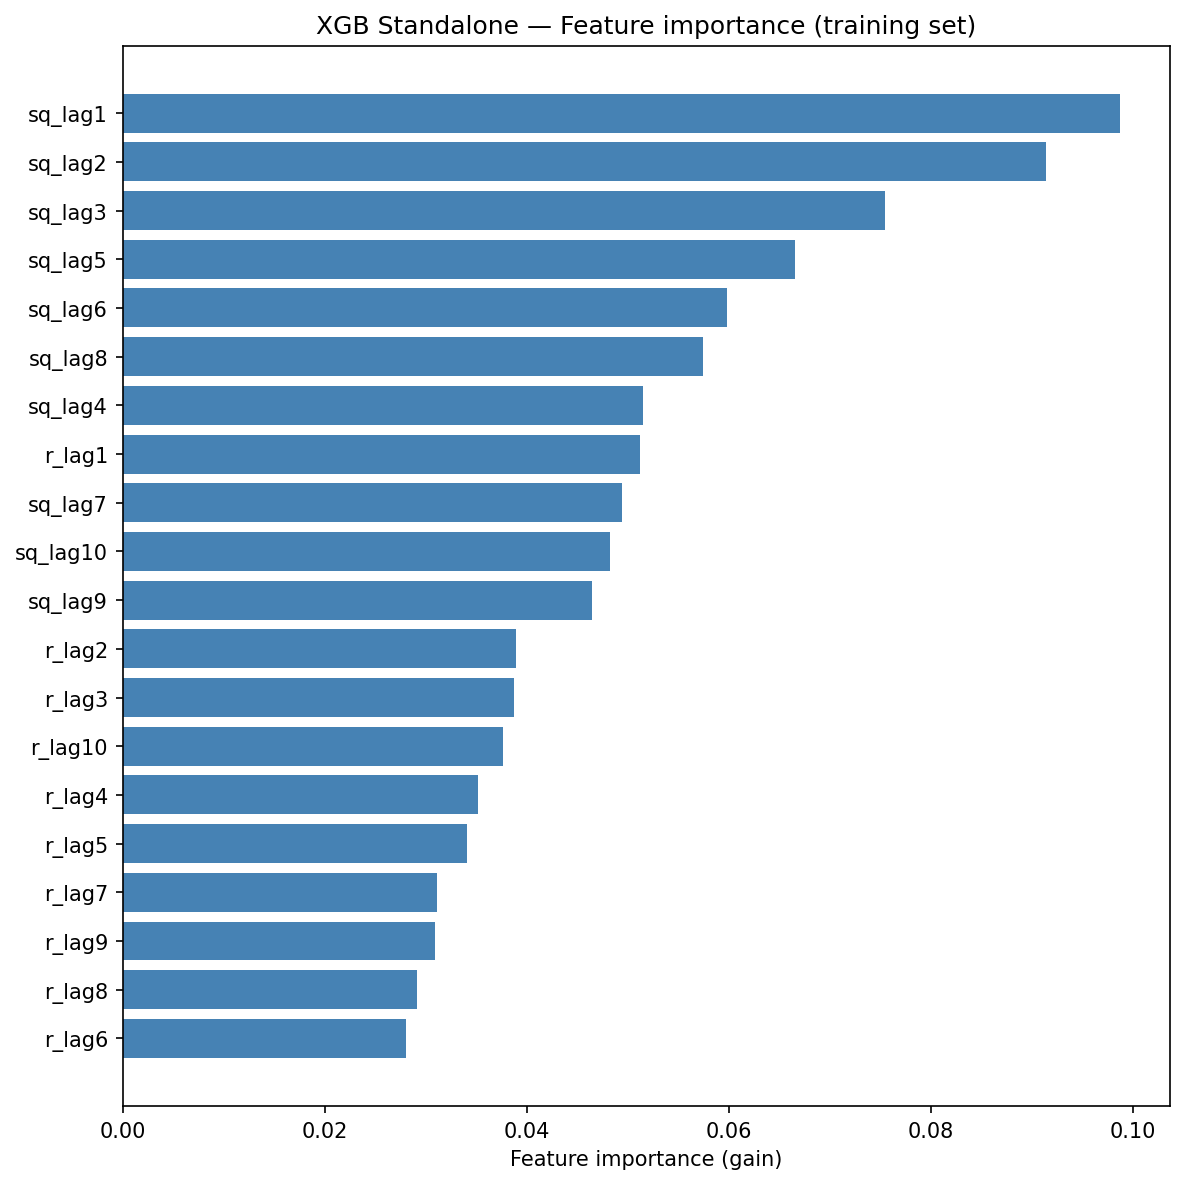

In [25]:
# Fit once on training data for inspection (separate from the rolling evaluation).
# Uses the same target the evaluation scores against, so the importances describe
# the model actually being evaluated rather than one fitted on squared returns.
xgb_viz = XGBVolatilityModel(
    n_lags=XGB_N_LAGS, use_returns=XGB_USE_RETURNS,
    tune="never", xgb_params=XGB_PARAMS,
)
xgb_viz.fit(train_returns, target=variance_proxy.reindex(train_returns.index))

feat_names   = xgb_viz.feature_names()
importances  = xgb_viz._model.feature_importances_
order        = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, max(3, len(feat_names) * 0.4)), dpi=150)
ax.barh([feat_names[i] for i in order], importances[order], color='steelblue')
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGB Standalone — Feature importance (training set)")
plt.tight_layout()
plt.show()

## 5.3 Forecast vs realized

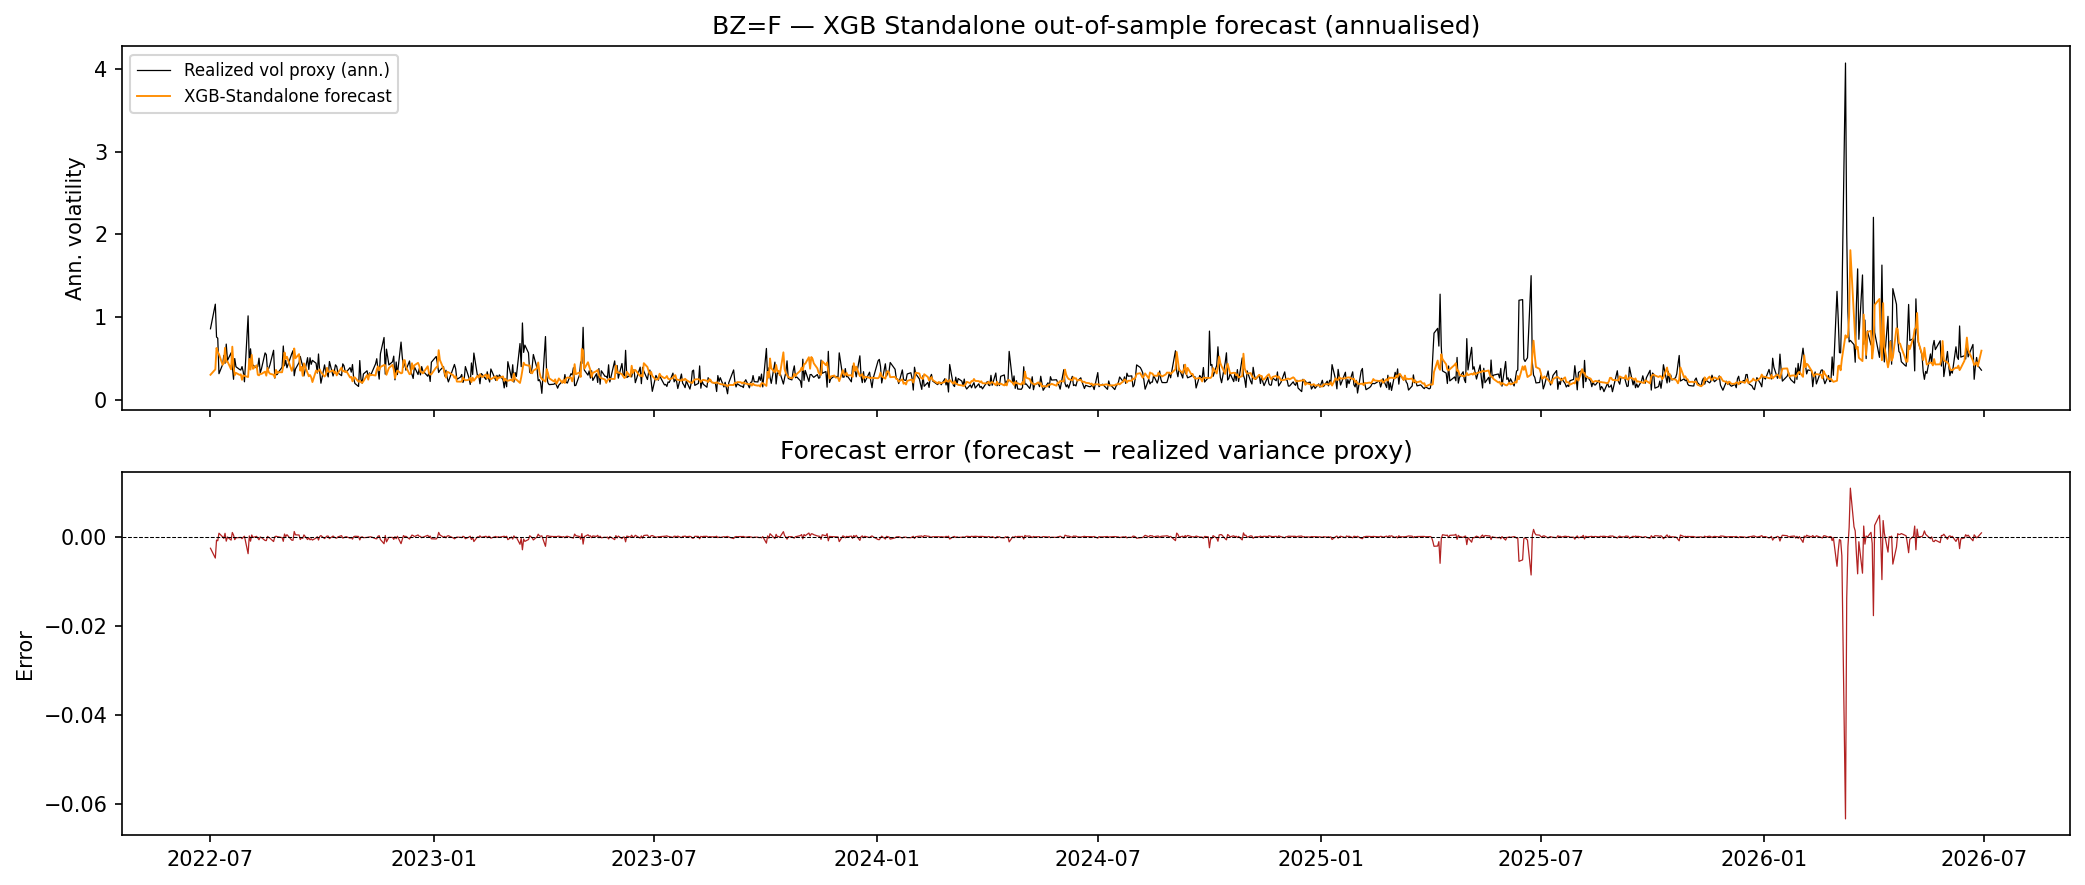

In [26]:
r_xgb = xgb_results["XGB-Standalone"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)
axes[0].plot(r_xgb.actuals.index.to_timestamp(), np.sqrt(r_xgb.actuals.values * 252),
             color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
axes[0].plot(r_xgb.forecasts.index.to_timestamp(), np.sqrt(r_xgb.forecasts.values * 252),
             color='darkorange', linewidth=0.9, label='XGB-Standalone forecast')
axes[0].set_title(f"{TICKER} — XGB Standalone out-of-sample forecast (annualised)")
axes[0].set_ylabel("Ann. volatility")
axes[0].legend(fontsize=8)
axes[1].plot(r_xgb.errors.index.to_timestamp(), r_xgb.errors.values,
             color='firebrick', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title("Forecast error (forecast − realized variance proxy)")
axes[1].set_ylabel("Error")
plt.tight_layout()
plt.show()

# 6. Hybrid XGBoost

Two hybrid architectures evaluated for each GARCH base model specified in `HYBRID_SPECS`:

| Mode | Description |
|------|-------------|
| `features` | XGB predicts variance directly; GARCH one-step forecast h_{t+1\|t} is included as an additional feature alongside lagged returns. |
| `residual` | **Residual correction**: final forecast = GARCH_forecast + XGB_residual, where XGB is trained to predict the in-sample GARCH residual (r²_t − h_{t\|t-1}). |

## 6.1 Out-of-sample evaluation

In [27]:
_mode_short = {"features": "feat", "residual": "resid"}

hybrid_eval_specs = [
    (
        tuned_factory(XGBHybridModel, tune=HYBRID_TUNE,
                garch_model_type=gt,
                garch_dist=gd,
                mode=m,
                n_lags=HYBRID_N_LAGS,
                use_returns=HYBRID_USE_RETURNS,
                n_trials=HYBRID_N_TRIALS,
                optuna_n_jobs=HYBRID_OPTUNA_JOBS,
                xgb_params=HYBRID_PARAMS),
        f"XGB-{gt}-{gd.upper()}-{_mode_short[m]}",
    )
    for gt, gd, m in HYBRID_SPECS
]

hybrid_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    hybrid_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    train_target_series=ml_train_target,
    verbose=True, n_jobs=PARALLEL_JOBS,
)
print(f"\nCompleted {len(hybrid_results)} hybrid model(s).")

Parallel evaluation: 15 models on 10 worker process(es)...
  [XGB-GJR-GARCH-GED-feat] done  RMSE=2.3496e-03
  [XGB-APARCH-NORMAL-feat] done  RMSE=2.3539e-03
  [XGB-GJR-GARCH-NORMAL-feat] done  RMSE=2.3365e-03
  [XGB-EGARCH-GED-feat] done  RMSE=2.3557e-03
  [XGB-EGARCH-NORMAL-feat] done  RMSE=2.3603e-03
  [XGB-GARCH-GED-feat] done  RMSE=2.3444e-03
  [XGB-GARCH-NORMAL-feat] done  RMSE=2.3246e-03
  [XGB-GJR-GARCH-T-feat] done  RMSE=2.3464e-03
  [XGB-APARCH-T-feat] done  RMSE=2.3552e-03
  [XGB-EGARCH-T-feat] done  RMSE=2.3628e-03
  [XGB-APARCH-GED-feat] done  RMSE=2.3528e-03
  [XGB-FIGARCH-T-feat] done  RMSE=2.3378e-03
  [XGB-GARCH-T-feat] done  RMSE=2.3329e-03
  [XGB-FIGARCH-NORMAL-feat] done  RMSE=2.3158e-03
  [XGB-FIGARCH-GED-feat] done  RMSE=2.3369e-03

Completed 15 hybrid model(s).


In [28]:
hybrid_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in hybrid_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
hybrid_metrics_df

,RMSE,MAE,MSE,QLIKE
XGB-FIGARCH-NORMAL-feat,0.002316,0.000446,0.000005,-6.601541
XGB-GARCH-NORMAL-feat,0.002325,0.000454,0.000005,-6.584239
XGB-GARCH-T-feat,0.002333,0.000462,0.000005,-6.457502
XGB-GJR-GARCH-NORMAL-feat,0.002336,0.000452,0.000005,-6.548277
XGB-FIGARCH-GED-feat,0.002337,0.000448,0.000005,-6.549432
XGB-FIGARCH-T-feat,0.002338,0.000450,0.000005,-6.567772
XGB-GARCH-GED-feat,0.002344,0.000450,0.000005,-6.515624
XGB-GJR-GARCH-T-feat,0.002346,0.000452,0.000006,-6.486347
XGB-GJR-GARCH-GED-feat,0.002350,0.000457,0.000006,-6.528125
XGB-APARCH-GED-feat,0.002353,0.000459,0.000006,-6.522342


## 6.2 Feature importance (hybrid models)

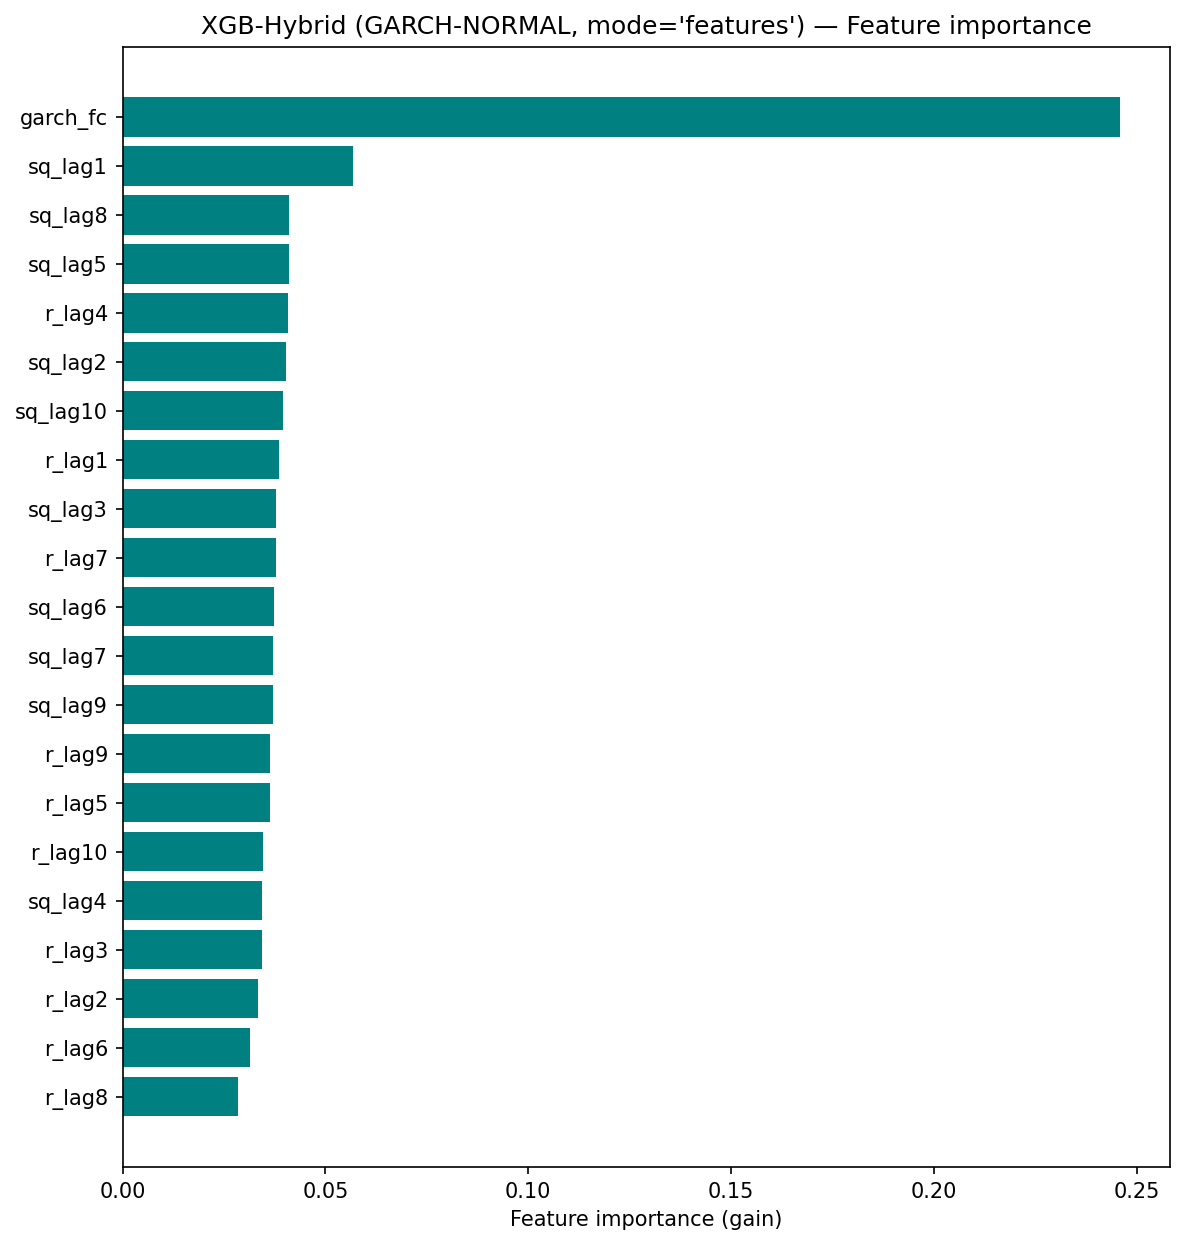

In [29]:
# Fit one representative hybrid model per mode for inspection.
# Same target as the evaluation (see the standalone section above).
# Uses the first spec for each mode found in HYBRID_SPECS
from collections import OrderedDict

viz_specs = OrderedDict()
for gt, gd, m in HYBRID_SPECS:
    if m not in viz_specs:
        viz_specs[m] = (gt, gd)

for mode, (gt, gd) in viz_specs.items():
    h_viz = XGBHybridModel(
        garch_model_type=gt, garch_dist=gd, mode=mode,
        n_lags=HYBRID_N_LAGS, use_returns=HYBRID_USE_RETURNS,
        tune="never", xgb_params=HYBRID_PARAMS,
    )
    h_viz.fit(train_returns, target=variance_proxy.reindex(train_returns.index))

    feat_names  = h_viz.feature_names()
    importances = h_viz._xgb.feature_importances_
    order       = np.argsort(importances)

    fig, ax = plt.subplots(figsize=(8, max(3, len(feat_names) * 0.4)), dpi=150)
    ax.barh([feat_names[i] for i in order], importances[order], color='teal')
    ax.set_xlabel("Feature importance (gain)")
    ax.set_title(f"XGB-Hybrid ({gt}-{gd.upper()}, mode='{mode}') — Feature importance")
    plt.tight_layout()
    plt.show()

## 6.3 Residual decomposition (residual-correction models)

In [30]:
# For each residual-mode hybrid in the results, plot the decomposition:
#   realized variance, GARCH standalone forecast, and final hybrid forecast

resid_names = [name for name in hybrid_results if name.endswith("-resid")]

# Identify corresponding GARCH standalone result for each residual hybrid
for h_name in resid_names:
    # derive base GARCH name from hybrid name, e.g. XGB-GARCH-NORMAL-resid → GARCH-NORMAL
    parts      = h_name.split("-")  # ['XGB', 'GARCH', 'NORMAL', 'resid']
    garch_name = "-".join(parts[1:-1])  # 'GARCH-NORMAL'

    r_h  = hybrid_results[h_name]
    r_g  = garch_results.get(garch_name)

    fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
    ax.plot(r_h.actuals.index.to_timestamp(), np.sqrt(r_h.actuals.values * 252),
            color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
    if r_g is not None:
        ax.plot(r_g.forecasts.index.to_timestamp(), np.sqrt(r_g.forecasts.values * 252),
                color='steelblue', linewidth=0.8, linestyle='--', label=f'{garch_name} (base GARCH)', alpha=0.8)
    ax.plot(r_h.forecasts.index.to_timestamp(), np.sqrt(r_h.forecasts.values * 252),
            color='darkorchid', linewidth=0.9, label=f'{h_name} (hybrid final)')
    ax.set_title(f"{TICKER} — Residual correction: {h_name}")
    ax.set_ylabel("Ann. volatility")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# 7. Standalone LSTM

LSTM trained on a rolling window of `[return, squared_return]` (winsorized, RobustScaler-scaled).
Target: next-step log(squared_return), RobustScaler-scaled, inverse-transformed and exponentiated
back to variance units at forecast time.

> **Retransformation correction.** Trained on log(r²) under MSE, the network estimates E[log r² | X],
> so a plain `exp()` of its output is the conditional *geometric* mean — not the conditional variance
> E[r² | X] that the GARCH and XGB models forecast and that RMSE/QLIKE score. Uncorrected, the LSTM
> forecast came out ≈0.2× the realized level on this data, which QLIKE punishes severely (−2.7 vs
> −6.2) and which pushed every LSTM out of the MCS. `LSTM_RETRANSFORM = "smearing"` applies the
> Duan (1983) smearing factor estimated on the fit residuals; set it to `"none"` to reproduce the
> uncorrected numbers.

## 7.1 Out-of-sample evaluation

In [31]:
lstm_eval_specs = [
    (
        tuned_factory(LSTMVolatilityModel, tune=LSTM_TUNE, n_trials=LSTM_N_TRIALS,
                lookback=LSTM_LOOKBACK,
                hidden_size=LSTM_HIDDEN_SIZE,
                num_layers=LSTM_NUM_LAYERS,
                dropout=LSTM_DROPOUT,
                lr=LSTM_LR,
                max_epochs=LSTM_MAX_EPOCHS,
                patience=LSTM_PATIENCE,
                batch_size=LSTM_BATCH_SIZE,
                val_fraction=LSTM_VAL_FRACTION,
                winsor_limits=LSTM_WINSOR_LIMITS,
                retransform=LSTM_RETRANSFORM,
                seed=RANDOM_SEED,
                device=LSTM_DEVICE),
        "LSTM-Standalone",
    )
]

lstm_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    lstm_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    train_target_series=ml_train_target,
    verbose=True, n_jobs=LSTM_PARALLEL_JOBS,
)
print(f"\nCompleted {len(lstm_results)} standalone LSTM model(s).")


Parallel evaluation: 1 models on 10 worker process(es)...
  [LSTM-Standalone] done  RMSE=2.3372e-03

Completed 1 standalone LSTM model(s).


In [32]:
lstm_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in lstm_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
lstm_metrics_df


,RMSE,MAE,MSE,QLIKE
LSTM-Standalone,0.002337,0.000466,0.000005,-6.563154


## 7.2 Forecast vs realized

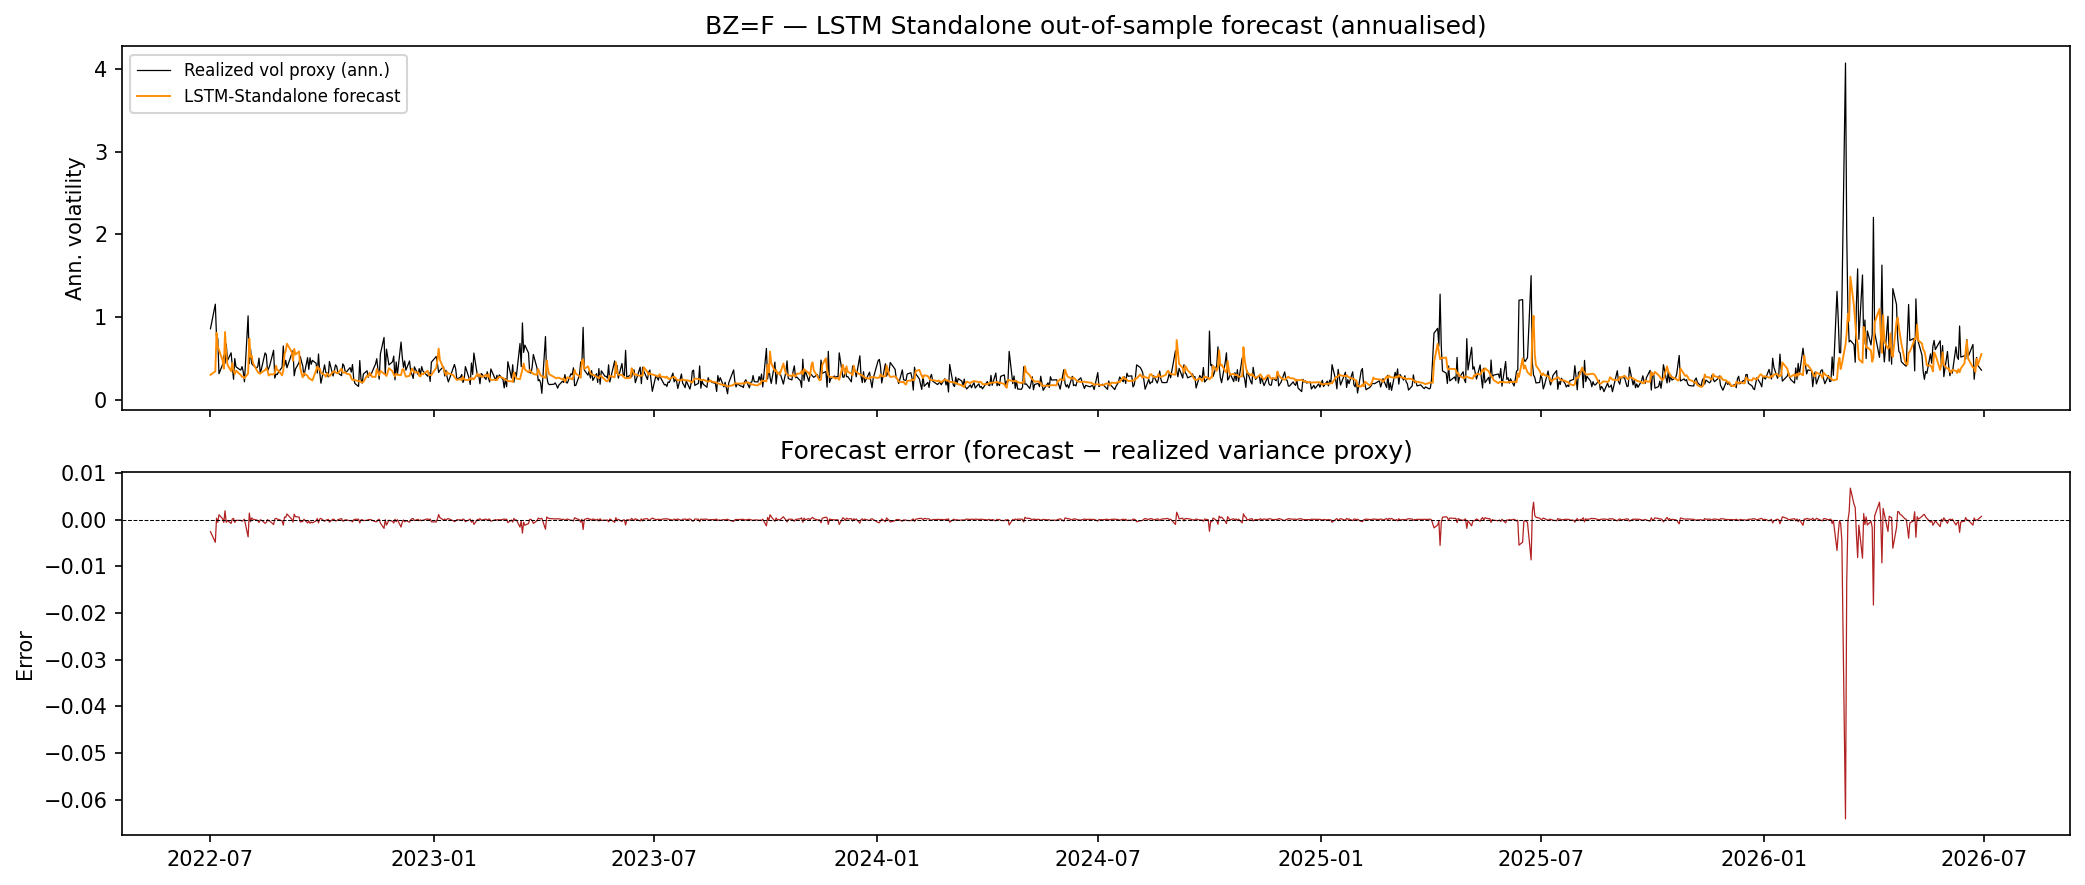

In [33]:
r_lstm = lstm_results["LSTM-Standalone"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)
axes[0].plot(r_lstm.actuals.index.to_timestamp(), np.sqrt(r_lstm.actuals.values * 252),
              color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
axes[0].plot(r_lstm.forecasts.index.to_timestamp(), np.sqrt(r_lstm.forecasts.values * 252),
              color='darkorange', linewidth=0.9, label='LSTM-Standalone forecast')
axes[0].set_title(f"{TICKER} — LSTM Standalone out-of-sample forecast (annualised)")
axes[0].set_ylabel("Ann. volatility")
axes[0].legend(fontsize=8)
axes[1].plot(r_lstm.errors.index.to_timestamp(), r_lstm.errors.values,
              color='firebrick', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title("Forecast error (forecast − realized variance proxy)")
axes[1].set_ylabel("Error")
plt.tight_layout()
plt.show()


# 8. Hybrid LSTM

Two hybrid architectures evaluated for each GARCH base model specified in `LSTM_HYBRID_SPECS`:

| Mode | Description |
|------|-------------|
| `features` | LSTM inputs are `[return, squared_return]` plus the GARCH one-step forecast h_{t+1\|t} (log-scaled), broadcast across every timestep of the lookback window. |
| `residual` | **Residual correction**: final forecast = GARCH_forecast + LSTM_residual, where LSTM is trained to predict the GARCH residual (r²_t − h_{t\|t-1}). |

`LSTM_RETRANSFORM` applies to `features` mode only — it shares the standalone model's log(r²) target.
`residual` mode is fit on the level scale (r²_t − h_{t|t-1}, which can be negative) and needs no
correction.

## 8.1 Out-of-sample evaluation

In [34]:
_mode_short = {"features": "feat", "residual": "resid"}

lstm_hybrid_eval_specs = [
    (
        tuned_factory(LSTMHybridModel, tune=LSTM_TUNE, n_trials=LSTM_N_TRIALS,
                garch_model_type=gt,
                garch_dist=gd,
                mode=m,
                lookback=LSTM_LOOKBACK,
                hidden_size=LSTM_HIDDEN_SIZE,
                num_layers=LSTM_NUM_LAYERS,
                dropout=LSTM_DROPOUT,
                lr=LSTM_LR,
                max_epochs=LSTM_MAX_EPOCHS,
                patience=LSTM_PATIENCE,
                batch_size=LSTM_BATCH_SIZE,
                val_fraction=LSTM_VAL_FRACTION,
                winsor_limits=LSTM_WINSOR_LIMITS,
                retransform=LSTM_RETRANSFORM,
                seed=RANDOM_SEED,
                device=LSTM_DEVICE),
        f"LSTM-{gt}-{gd.upper()}-{_mode_short[m]}",
    )
    for gt, gd, m in LSTM_HYBRID_SPECS
]

lstm_hybrid_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    lstm_hybrid_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    train_target_series=ml_train_target,
    verbose=True, n_jobs=LSTM_PARALLEL_JOBS,
)
print(f"\nCompleted {len(lstm_hybrid_results)} hybrid LSTM model(s).")


Parallel evaluation: 15 models on 10 worker process(es)...
  [LSTM-GJR-GARCH-NORMAL-feat] done  RMSE=2.3473e-03
  [LSTM-GJR-GARCH-GED-feat] done  RMSE=2.3444e-03
  [LSTM-GJR-GARCH-T-feat] done  RMSE=2.3428e-03
  [LSTM-EGARCH-GED-feat] done  RMSE=2.3384e-03
  [LSTM-EGARCH-T-feat] done  RMSE=2.3451e-03
  [LSTM-GARCH-GED-feat] done  RMSE=2.3237e-03
  [LSTM-GARCH-NORMAL-feat] done  RMSE=2.3220e-03
  [LSTM-GARCH-T-feat] done  RMSE=2.3243e-03
  [LSTM-EGARCH-NORMAL-feat] done  RMSE=2.3237e-03
  [LSTM-APARCH-NORMAL-feat] done  RMSE=2.3247e-03
  [LSTM-FIGARCH-NORMAL-feat] done  RMSE=2.3309e-03
  [LSTM-FIGARCH-T-feat] done  RMSE=2.3274e-03
  [LSTM-FIGARCH-GED-feat] done  RMSE=2.3277e-03
  [LSTM-APARCH-T-feat] done  RMSE=2.3263e-03
  [LSTM-APARCH-GED-feat] done  RMSE=2.3260e-03

Completed 15 hybrid LSTM model(s).


In [35]:
lstm_hybrid_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in lstm_hybrid_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
lstm_hybrid_metrics_df


,RMSE,MAE,MSE,QLIKE
LSTM-GARCH-NORMAL-feat,0.002322,0.000449,0.000005,-6.589326
LSTM-GARCH-GED-feat,0.002324,0.000448,0.000005,-6.586384
LSTM-EGARCH-NORMAL-feat,0.002324,0.000445,0.000005,-6.585205
LSTM-GARCH-T-feat,0.002324,0.000448,0.000005,-6.586105
LSTM-APARCH-NORMAL-feat,0.002325,0.000451,0.000005,-6.583223
LSTM-APARCH-GED-feat,0.002326,0.000450,0.000005,-6.584931
LSTM-APARCH-T-feat,0.002326,0.000448,0.000005,-6.583206
LSTM-FIGARCH-T-feat,0.002327,0.000451,0.000005,-6.553903
LSTM-FIGARCH-GED-feat,0.002328,0.000457,0.000005,-6.554799
LSTM-FIGARCH-NORMAL-feat,0.002331,0.000455,0.000005,-6.546431


## 8.2 Residual decomposition (residual-correction models)

In [36]:
# For each residual-mode hybrid in the results, plot the decomposition:
#   realized variance, GARCH standalone forecast, and final hybrid forecast

resid_names = [name for name in lstm_hybrid_results if name.endswith("-resid")]

for h_name in resid_names:
    # derive base GARCH name from hybrid name, e.g. LSTM-GARCH-NORMAL-resid → GARCH-NORMAL
    parts      = h_name.split("-")  # ['LSTM', 'GARCH', 'NORMAL', 'resid']
    garch_name = "-".join(parts[1:-1])  # 'GARCH-NORMAL'

    r_h  = lstm_hybrid_results[h_name]
    r_g  = garch_results.get(garch_name)

    fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
    ax.plot(r_h.actuals.index.to_timestamp(), np.sqrt(r_h.actuals.values * 252),
            color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
    if r_g is not None:
        ax.plot(r_g.forecasts.index.to_timestamp(), np.sqrt(r_g.forecasts.values * 252),
                color='steelblue', linewidth=0.8, linestyle='--', label=f'{garch_name} (base GARCH)', alpha=0.8)
    ax.plot(r_h.forecasts.index.to_timestamp(), np.sqrt(r_h.forecasts.values * 252),
            color='darkorchid', linewidth=0.9, label=f'{h_name} (hybrid final)')
    ax.set_title(f"{TICKER} — Residual correction: {h_name}")
    ax.set_ylabel("Ann. volatility")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# 9. Joint Evaluation — All Models

Combined metrics table and forecast overlay across all model groups.

> **Note on QLIKE.** The reported QLIKE is `mean(log h_t + proxy_t / h_t)`, which equals the Patton (2011) robust QLIKE up to a model-independent additive constant. Only *differences* and the *ordering* across models are interpretable — the absolute level (e.g. −6.6) carries no meaning on its own. DM and MCS (which use loss differences) are unaffected by the constant.

> **Note on RMSE across proxies.** RMSE magnitudes are not comparable between different `VARIANCE_PROXY` settings (the target variable differs). Compare RMSE only *within* a single proxy; across proxies, rely on the ranking / QLIKE.

In [37]:
all_results: dict[str, ForecastResult] = {
    **garch_results,
    **realized_results,
    **xgb_results,
    **hybrid_results,
    **lstm_results,
    **lstm_hybrid_results,
}

# Guard the merge. A group that was never run (or was lost to a kernel restart)
# would silently vanish from every joint table, the DM matrix and the MCS below,
# and a name reused across two groups would be overwritten without any error.
# Both failure modes look identical from the outside: "my models aren't there".
_sources = {
    "garch_results":       garch_results,
    "xgb_results":         xgb_results,
    "hybrid_results":      hybrid_results,
    "lstm_results":        lstm_results,
    "lstm_hybrid_results": lstm_hybrid_results,
}
# Realized GARCH is optional — REALIZED_GARCH_SPECS = [] deliberately skips 4.3 —
# so it only joins the guard when it was actually asked for.
if REALIZED_GARCH_SPECS:
    _sources["realized_results"] = realized_results

_missing = [k for k, v in _sources.items() if not v]
if _missing:
    raise RuntimeError(f"Model group(s) empty: {_missing} — re-run those sections first.")

_n_evaluated = sum(len(v) for v in _sources.values())
if len(all_results) != _n_evaluated:
    _lost = _n_evaluated - len(all_results)
    raise RuntimeError(
        f"all_results holds {len(all_results)} models, but {_n_evaluated} were "
        f"evaluated across {list(_sources)}. "
        + (f"{_lost} name(s) collided and were silently overwritten by the merge."
           if _lost > 0 else
           f"{-_lost} model(s) in all_results come from a group missing from "
           f"_sources — add it there so the guard can see it.")
    )


def _group(name: str) -> str:
    if name.startswith("XGB-") and "-feat" in name:
        return "XGB Hybrid (features)"
    if name.startswith("XGB-") and "-resid" in name:
        return "XGB Hybrid (residual)"
    if name.startswith("XGB-"):
        return "Standalone XGB"
    if name.startswith("LSTM-") and "-feat" in name:
        return "LSTM Hybrid (features)"
    if name.startswith("LSTM-") and "-resid" in name:
        return "LSTM Hybrid (residual)"
    if name.startswith("LSTM-"):
        return "Standalone LSTM"
    if name.startswith("RealGARCH-"):
        return "Realized GARCH"
    return "GARCH"


all_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in all_results.items()})
    .T
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
all_metrics_df.insert(0, "Group", all_metrics_df.index.map(_group))
all_metrics_df = all_metrics_df.sort_values(["Group", "RMSE"])

print(f"{len(all_metrics_df)} models across {all_metrics_df['Group'].nunique()} groups:")
print(all_metrics_df["Group"].value_counts().to_string(), "\n")

# Best model per group, so no group can be hidden by the global ranking.
print("Best model per group (lowest QLIKE — the loss DM and MCS use):")
print(
    all_metrics_df.sort_values("QLIKE").groupby("Group", sort=False).head(1)
    .to_string(float_format=lambda v: f"{v:.6e}"),
    "\n",
)

# Full table — every model, every group. This cell used to display only
# .head(10) of the global RMSE ranking, which silently dropped whole groups
# (no LSTM model ever ranked top-10 on RMSE, so the "all models" table showed
# none of them).
all_metrics_df.sort_values("QLIKE")

50 models across 6 groups:
Group
GARCH                     15
LSTM Hybrid (features)    15
XGB Hybrid (features)     15
Realized GARCH             3
Standalone LSTM            1
Standalone XGB             1 

Best model per group (lowest QLIKE — the loss DM and MCS use):
                                                   Group         RMSE          MAE          MSE         QLIKE
FIGARCH-NORMAL                                     GARCH 2.303624e-03 4.614699e-04 5.306684e-06 -6.662696e+00
RealGARCH-garman_klass_overnight          Realized GARCH 2.304302e-03 5.033943e-04 5.309806e-06 -6.638990e+00
XGB-FIGARCH-NORMAL-feat            XGB Hybrid (features) 2.315849e-03 4.464380e-04 5.363158e-06 -6.601541e+00
LSTM-GARCH-NORMAL-feat            LSTM Hybrid (features) 2.322034e-03 4.494161e-04 5.391840e-06 -6.589326e+00
LSTM-Standalone                          Standalone LSTM 2.337192e-03 4.659688e-04 5.462465e-06 -6.563154e+00
XGB-Standalone                            Standalone XGB 2.337817e-0

,Group,RMSE,MAE,MSE,QLIKE
FIGARCH-NORMAL,GARCH,0.002304,0.000461,0.000005,-6.662696
FIGARCH-GED,GARCH,0.002309,0.000457,0.000005,-6.656476
GARCH-NORMAL,GARCH,0.002306,0.000463,0.000005,-6.654321
FIGARCH-T,GARCH,0.002310,0.000458,0.000005,-6.654244
GARCH-GED,GARCH,0.002311,0.000459,0.000005,-6.646201
GARCH-T,GARCH,0.002312,0.000464,0.000005,-6.645537
RealGARCH-garman_klass_overnight,Realized GARCH,0.002304,0.000503,0.000005,-6.638990
RealGARCH-rogers_satchell_overnight,Realized GARCH,0.002310,0.000505,0.000005,-6.629458
GJR-GARCH-NORMAL,GARCH,0.002334,0.000476,0.000005,-6.605694
XGB-FIGARCH-NORMAL-feat,XGB Hybrid (features),0.002316,0.000446,0.000005,-6.601541


In [38]:
# Forecast-sanity screen across ALL model groups. Two independent failures are
# flagged:
#   degenerate — forecasts numerically broken (variance collapsing toward 0 blows
#                up QLIKE; exploding upward blows up RMSE). One such model
#                poisons the joint metrics, the DM matrix and the MCS for
#                everyone. Observed with EGARCH on short (~500-obs) windows.
#   biased     — forecasts finite and smooth but at the wrong LEVEL, i.e.
#                mean(forecast)/mean(proxy) off by more than 2x. Every model here
#                forecasts the same E[r^2], so this ratio should sit near 1. This
#                catches transform errors (e.g. exponentiating a log-scale target
#                without a retransformation correction), which the degeneracy
#                screen alone passes as clean while QLIKE and the MCS reject the
#                model outright.
diag_df = forecast_diagnostics(all_results)  # warns per affected model

_bad = diag_df.index[diag_df["degenerate"]].tolist()
if _bad:
    print(f"\u26a0 DEGENERATE models — exclude before trusting DM/MCS: {_bad}\n")
else:
    print("\u2713 No degenerate forecasts — metrics are trustworthy.\n")

_biased = diag_df.index[diag_df["biased"] & ~diag_df["degenerate"]].tolist()
if _biased:
    print(f"\u26a0 MIS-SCALED models (mean forecast off by >2x — check the model, "
          f"not the tests): {_biased}\n")
else:
    print("\u2713 All forecasts on the right scale (mean forecast within 2x of the proxy).\n")

diag_df[["n", "min_forecast", "max_forecast", "n_extreme_low",
         "n_extreme_high", "bias_ratio", "RMSE", "QLIKE",
         "degenerate", "biased"]].style.map(
    lambda v: "background-color: #ffcdd2; font-weight: bold" if v is True else "",
    subset=["degenerate", "biased"],
).format({"min_forecast": "{:.2e}", "max_forecast": "{:.2e}", "bias_ratio": "{:.2f}",
          "RMSE": "{:.3e}", "QLIKE": "{:.3e}"})

✓ No degenerate forecasts — metrics are trustworthy.

✓ All forecasts on the right scale (mean forecast within 2x of the proxy).



,n,min_forecast,max_forecast,n_extreme_low,n_extreme_high,bias_ratio,RMSE,QLIKE,degenerate,biased
XGB-EGARCH-T-feat,1004,2.64e-05,9.20e-03,0,0,0.66,2.363e-03,-6.448e+00,False,False
XGB-GARCH-T-feat,1004,2.09e-05,1.05e-02,0,0,0.63,2.333e-03,-6.458e+00,False,False
XGB-GJR-GARCH-T-feat,1004,3.26e-05,7.49e-03,0,0,0.63,2.346e-03,-6.486e+00,False,False
XGB-EGARCH-GED-feat,1004,3.39e-05,1.03e-02,0,0,0.69,2.356e-03,-6.491e+00,False,False
XGB-APARCH-T-feat,1004,4.70e-05,6.79e-03,0,0,0.66,2.355e-03,-6.507e+00,False,False
XGB-EGARCH-NORMAL-feat,1004,4.40e-05,1.03e-02,0,0,0.69,2.360e-03,-6.515e+00,False,False
XGB-GARCH-GED-feat,1004,4.51e-05,7.82e-03,0,0,0.63,2.344e-03,-6.516e+00,False,False
APARCH-T,1004,1.06e-04,4.62e-03,0,0,0.85,2.351e-03,-6.520e+00,False,False
XGB-APARCH-GED-feat,1004,6.45e-05,7.86e-03,0,0,0.72,2.353e-03,-6.522e+00,False,False
EGARCH-T,1004,1.02e-04,3.96e-03,0,0,0.86,2.351e-03,-6.523e+00,False,False


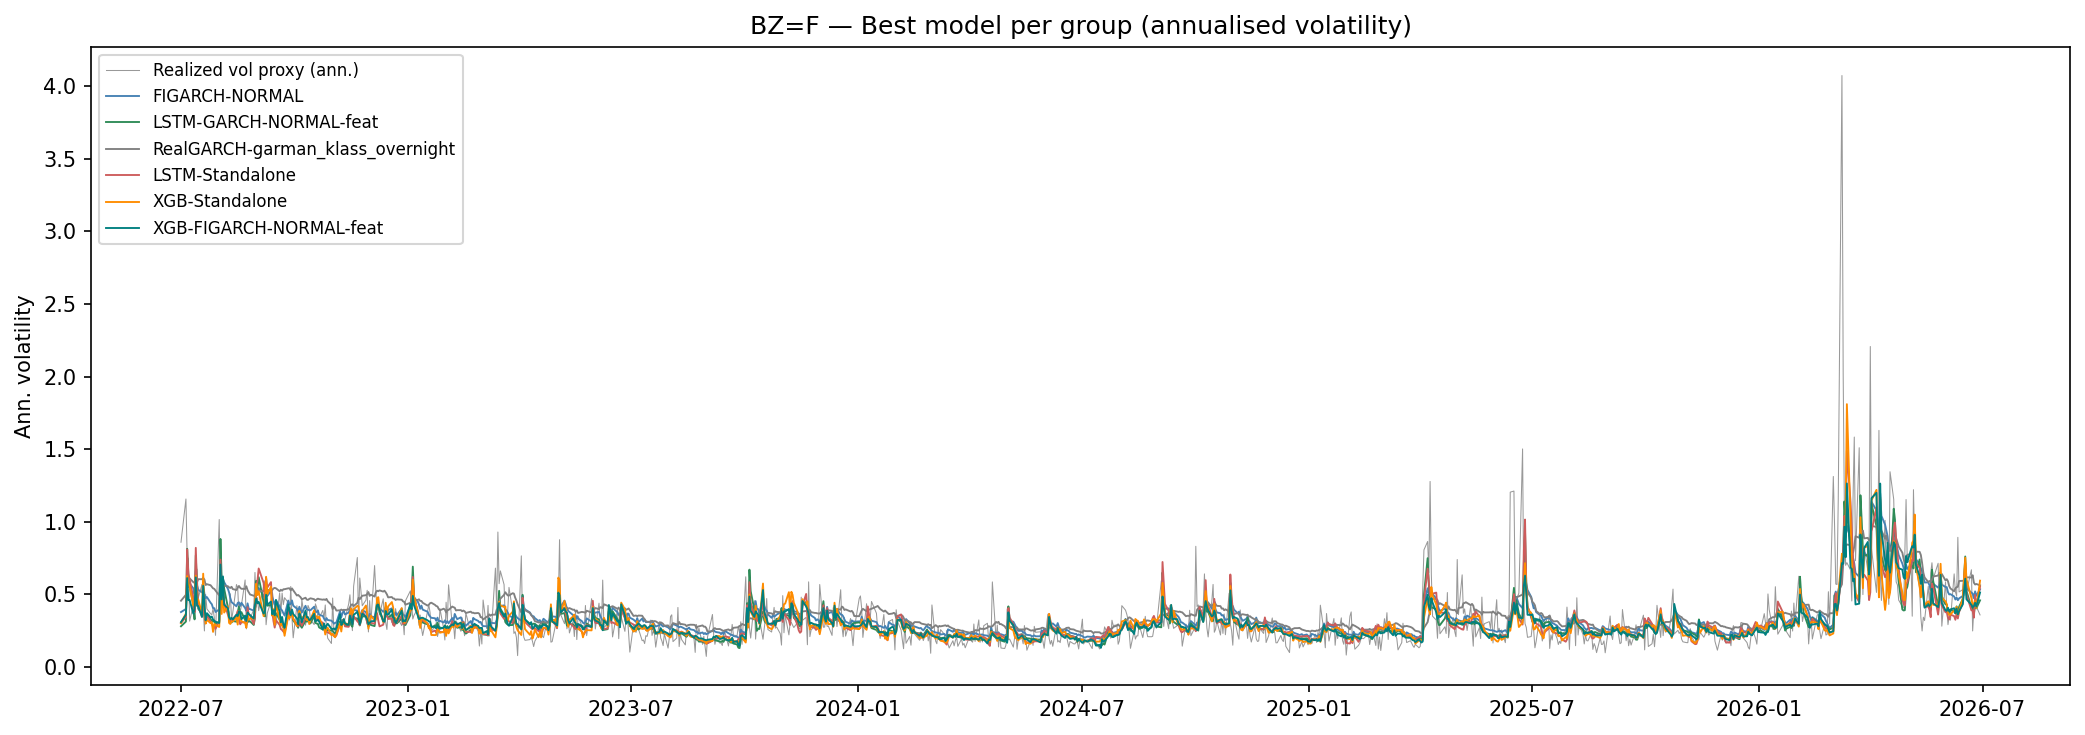

In [39]:
# Best model per group + realized variance overlay
groups = all_metrics_df["Group"].unique()
palette = {
    "GARCH": "steelblue",
    "Standalone XGB": "darkorange",
    "XGB Hybrid (features)": "teal",
    "XGB Hybrid (residual)": "darkorchid",
    "Standalone LSTM": "indianred",
    "LSTM Hybrid (features)": "seagreen",
    "LSTM Hybrid (residual)": "goldenrod",
}

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)
# realized vol proxy (use any result's actuals — they are identical)
ref = next(iter(all_results.values()))
ax.plot(ref.actuals.index.to_timestamp(), np.sqrt(ref.actuals.values * 252),
        color='black', linewidth=0.5, alpha=0.4, label='Realized vol proxy (ann.)')

for grp in groups:
    best_name = all_metrics_df[all_metrics_df["Group"] == grp].sort_values("RMSE").index[0]
    r = all_results[best_name]
    ax.plot(r.forecasts.index.to_timestamp(), np.sqrt(r.forecasts.values * 252),
            linewidth=0.9, label=f"{best_name}", color=palette.get(grp, 'gray'))

ax.set_title(f"{TICKER} — Best model per group (annualised volatility)")
ax.set_ylabel("Ann. volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# 10. Statistical Tests

All model groups evaluated jointly.

## 10.1 Diebold-Mariano Test (HLN correction)

Pairwise test of equal predictive accuracy (Harvey, Leybourne & Newbold 1997).  
H₀: models *i* and *j* have equal expected loss.  
Negative MDM statistic → row model has lower loss than column model.  
p-values two-sided from *t*(T−1).

In [40]:
dm_stat_df, dm_pval_df = dm_matrix(all_results, h=N_AHEAD, loss=TEST_LOSS)

print("MDM statistics (upper triangle):")
dm_stat_df.round(3)

MDM statistics (upper triangle):


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,...,LSTM-GJR-GARCH-GED-feat,LSTM-EGARCH-NORMAL-feat,LSTM-EGARCH-T-feat,LSTM-EGARCH-GED-feat,LSTM-APARCH-NORMAL-feat,LSTM-APARCH-T-feat,LSTM-APARCH-GED-feat,LSTM-FIGARCH-NORMAL-feat,LSTM-FIGARCH-T-feat,LSTM-FIGARCH-GED-feat
GARCH-NORMAL,NaN,-1.586,-1.691,-2.047,-1.901,-1.939,-1.849,-1.782,-1.789,-1.828,...,-3.545,-3.251,-3.386,-3.405,-3.580,-3.482,-3.459,-2.850,-2.417,-2.464
GARCH-T,NaN,NaN,0.555,-2.110,-1.946,-1.986,-1.862,-1.789,-1.796,-1.837,...,-2.896,-2.668,-3.194,-3.175,-3.014,-3.056,-2.978,-2.585,-2.207,-2.232
GARCH-GED,NaN,NaN,NaN,-2.095,-1.927,-1.970,-1.855,-1.783,-1.790,-1.831,...,-3.032,-2.794,-3.268,-3.255,-3.164,-3.189,-3.117,-2.638,-2.246,-2.274
GJR-GARCH-NORMAL,NaN,NaN,NaN,NaN,-1.030,-1.195,-1.679,-1.619,-1.614,-1.658,...,-0.812,-0.677,-1.821,-1.702,-0.820,-0.893,-0.800,-1.454,-1.240,-1.213
GJR-GARCH-T,NaN,NaN,NaN,NaN,NaN,0.292,-1.773,-1.682,-1.683,-1.739,...,-0.522,-0.400,-1.398,-1.291,-0.496,-0.537,-0.466,-1.176,-0.997,-0.968
GJR-GARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,-1.736,-1.655,-1.654,-1.708,...,-0.553,-0.428,-1.468,-1.356,-0.530,-0.576,-0.501,-1.219,-1.033,-1.004
EGARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.437,-1.311,-0.278,...,0.568,0.663,0.223,0.261,0.659,0.692,0.709,0.043,0.155,0.165
EGARCH-T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.618,1.406,...,0.730,0.813,0.483,0.507,0.814,0.848,0.859,0.289,0.388,0.392
EGARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.234,...,0.660,0.747,0.379,0.408,0.747,0.780,0.793,0.190,0.293,0.299
APARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.575,0.668,0.236,0.273,0.666,0.699,0.715,0.056,0.168,0.178


In [41]:
print(f"DM p-values — highlighted: p < {DM_ALPHA}")
dm_pval_df.round(4).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold"
    if (not pd.isna(v) and v < DM_ALPHA) else "",
)

DM p-values — highlighted: p < 0.05


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED,RealGARCH-garman_klass,RealGARCH-garman_klass_overnight,RealGARCH-rogers_satchell_overnight,XGB-Standalone,XGB-GARCH-NORMAL-feat,XGB-GARCH-T-feat,XGB-GARCH-GED-feat,XGB-GJR-GARCH-NORMAL-feat,XGB-GJR-GARCH-T-feat,XGB-GJR-GARCH-GED-feat,XGB-EGARCH-NORMAL-feat,XGB-EGARCH-T-feat,XGB-EGARCH-GED-feat,XGB-APARCH-NORMAL-feat,XGB-APARCH-T-feat,XGB-APARCH-GED-feat,XGB-FIGARCH-NORMAL-feat,XGB-FIGARCH-T-feat,XGB-FIGARCH-GED-feat,LSTM-Standalone,LSTM-GARCH-NORMAL-feat,LSTM-GARCH-T-feat,LSTM-GARCH-GED-feat,LSTM-GJR-GARCH-NORMAL-feat,LSTM-GJR-GARCH-T-feat,LSTM-GJR-GARCH-GED-feat,LSTM-EGARCH-NORMAL-feat,LSTM-EGARCH-T-feat,LSTM-EGARCH-GED-feat,LSTM-APARCH-NORMAL-feat,LSTM-APARCH-T-feat,LSTM-APARCH-GED-feat,LSTM-FIGARCH-NORMAL-feat,LSTM-FIGARCH-T-feat,LSTM-FIGARCH-GED-feat
GARCH-NORMAL,nan,0.113100,0.091200,0.040900,0.057600,0.052800,0.064700,0.075000,0.073900,0.067900,0.079400,0.076100,0.206700,0.985900,0.617600,0.016600,0.361900,0.205600,0.000800,0.000000,0.000000,0.000000,0.000100,0.000000,0.000000,0.000100,0.000000,0.000200,0.000300,0.000300,0.000600,0.007400,0.000000,0.000000,0.000100,0.000200,0.000100,0.000100,0.000400,0.000400,0.000400,0.001200,0.000700,0.000700,0.000400,0.000500,0.000600,0.004500,0.015800,0.013900
GARCH-T,nan,nan,0.578900,0.035100,0.052000,0.047300,0.062900,0.074000,0.072800,0.066500,0.078700,0.075200,0.139000,0.161200,0.156500,0.017200,0.653500,0.329400,0.005100,0.001100,0.000000,0.000000,0.000100,0.000000,0.000000,0.000100,0.000000,0.000400,0.000600,0.000200,0.000700,0.054100,0.000300,0.000300,0.001200,0.004700,0.001900,0.002100,0.004600,0.003400,0.003900,0.007700,0.001400,0.001500,0.002600,0.002300,0.003000,0.009900,0.027600,0.025800
GARCH-GED,nan,nan,nan,0.036500,0.054300,0.049100,0.064000,0.074900,0.073800,0.067400,0.079600,0.076100,0.128800,0.145300,0.138800,0.020800,0.639400,0.335100,0.003700,0.000500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000100,0.000000,0.000300,0.000400,0.000200,0.000600,0.041200,0.000100,0.000200,0.000700,0.002700,0.001000,0.001100,0.002900,0.002200,0.002500,0.005300,0.001100,0.001200,0.001600,0.001500,0.001900,0.008500,0.024900,0.023200
GJR-GARCH-NORMAL,nan,nan,nan,nan,0.303500,0.232400,0.093500,0.105800,0.106900,0.097700,0.110500,0.109200,0.046900,0.030500,0.035900,0.777700,0.174300,0.299600,0.226500,0.474600,0.002100,0.003100,0.001900,0.001200,0.000800,0.002100,0.000000,0.008500,0.016000,0.000200,0.004900,0.905000,0.204500,0.103100,0.203900,0.600400,0.503600,0.517000,0.439800,0.391000,0.417000,0.498700,0.068900,0.089000,0.412600,0.371900,0.423700,0.146200,0.215400,0.225500
GJR-GARCH-T,nan,nan,nan,nan,nan,0.770700,0.076600,0.092900,0.092700,0.082400,0.098900,0.095800,0.063000,0.047100,0.053000,0.993900,0.144600,0.223700,0.346300,0.668100,0.007000,0.015400,0.019900,0.005200,0.004500,0.009600,0.000200,0.021500,0.048300,0.000600,0.016200,0.956500,0.365700,0.205700,0.350000,0.784000,0.700900,0.711300,0.621300,0.575400,0.602100,0.689300,0.162500,0.197100,0.620300,0.591500,0.641300,0.240000,0.319200,0.333300
GJR-GARCH-GED,nan,nan,nan,nan,nan,nan,0.082900,0.098200,0.098400,0.087900,0.103500,0.101100,0.058200,0.042400,0.048000,0.989800,0.149400,0.234600,0.328000,0.647400,0.005700,0.011700,0.012500,0.003900,0.003000,0.006900,0.000100,0.017800,0.039100,0.000400,0.012100,0.964700,0.341900,0.187100,0.327800,0.767000,0.680600,0.691600,0.600500,0.553100,0.580300,0.668800,0.142500,0.175500,0.596100,0.564800,0.616400,0.223100,0.301700,0.315500
EGARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,0.151200,0.190200,0.781200,0.164800,0.218400,0.065800,0.057500,0.060700,0.237600,0.081500,0.093400,0.885900,0.527800,0.269900,0.644800,0.918100,0.369700,0.744600,0.589300,0.084300,0.431500,0.794300,0.363900,0.673300,0.402000,0.699300,0.928800,0.765500,0.484700,0.501100,0.502300,0.573400,0.582000,0.570500,0.507400,0.823500,0.794500,0.510000,0

### 10.1.1 DM within-group vs between-group split

With 29 models there are 406 pairwise DM tests. Two effects inflate the raw count of significant pairs, so it should not be read at face value:

1. **Multiplicity.** ~20 pairs would be significant at 5% by chance alone, with no family-wise correction (that is what the MCS provides).
2. **(Near-)nesting.** Within the GARCH group, models differing only in the error distribution (e.g. GARCH-NORMAL vs GARCH-T, where Normal is the limiting case of the Student-t) are nearly nested — the loss-differential variance is near-degenerate under H₀, which inflates the DM statistic and makes the standard test oversized (Clark-McCracken; Giacomini-White 2006). A similar caveat applies to hybrid models sharing the same GARCH core.

The split below uses the model **groups** (GARCH / Standalone XGB / XGB Hybrid features / XGB Hybrid residual / Standalone LSTM / LSTM Hybrid features / LSTM Hybrid residual):

- **Between-group** pairs are the core research comparison — *do the ML and hybrid models forecast differently from the GARCH baseline (and from each other)?* These are properly non-nested and the most meaningful.
- **Within-group** pairs (especially inside the GARCH group) carry the nesting/oversizing caveat and should be interpreted with caution.

In [42]:
# Partition the 406 DM pairs by model GROUP (GARCH / XGB / LSTM / hybrids) via _group.
split = dm_family_split(dm_pval_df, alpha=DM_ALPHA, family_of=_group)

total_sig   = split["within"]["n_significant"] + split["between"]["n_significant"]
total_pairs = split["within"]["n_total"] + split["between"]["n_total"]
print(f"DM significant pairs ({TEST_LOSS} loss, p < {DM_ALPHA}): "
      f"{total_sig} / {total_pairs} total\n")

summary_split = pd.DataFrame({
    "n_significant": [split["within"]["n_significant"], split["between"]["n_significant"]],
    "n_total":       [split["within"]["n_total"],       split["between"]["n_total"]],
    "rejection_rate":[split["within"]["rate"],          split["between"]["rate"]],
}, index=["within-group", "between-group (research comparison)"])
print(summary_split.to_string(formatters={"rejection_rate": "{:.1%}".format}))

# Most-rejected models among between-group pairs — surfaces which models are
# genuinely distinguishable across the GARCH / XGB / LSTM / hybrid boundaries.
from collections import Counter
node = Counter()
for a, b, p in split["between"]["pairs"]:
    if p < DM_ALPHA:
        node[a] += 1
        node[b] += 1
print("\nMost frequently rejected models (between-group pairs):")
for name, cnt in node.most_common(8):
    print(f"  {name:<24} [{_group(name):<18}] in {cnt} significant between-group pairs")

DM significant pairs (qlike loss, p < 0.05): 469 / 1225 total

                                     n_significant  n_total rejection_rate
within-group                                    69      318          21.7%
between-group (research comparison)            400      907          44.1%

Most frequently rejected models (between-group pairs):
  FIGARCH-GED              [GARCH             ] in 33 significant between-group pairs
  FIGARCH-NORMAL           [GARCH             ] in 33 significant between-group pairs
  FIGARCH-T                [GARCH             ] in 33 significant between-group pairs
  GARCH-NORMAL             [GARCH             ] in 33 significant between-group pairs
  GARCH-GED                [GARCH             ] in 33 significant between-group pairs
  GARCH-T                  [GARCH             ] in 32 significant between-group pairs
  XGB-GARCH-T-feat         [XGB Hybrid (features)] in 29 significant between-group pairs
  XGB-EGARCH-T-feat        [XGB Hybrid (features)] 

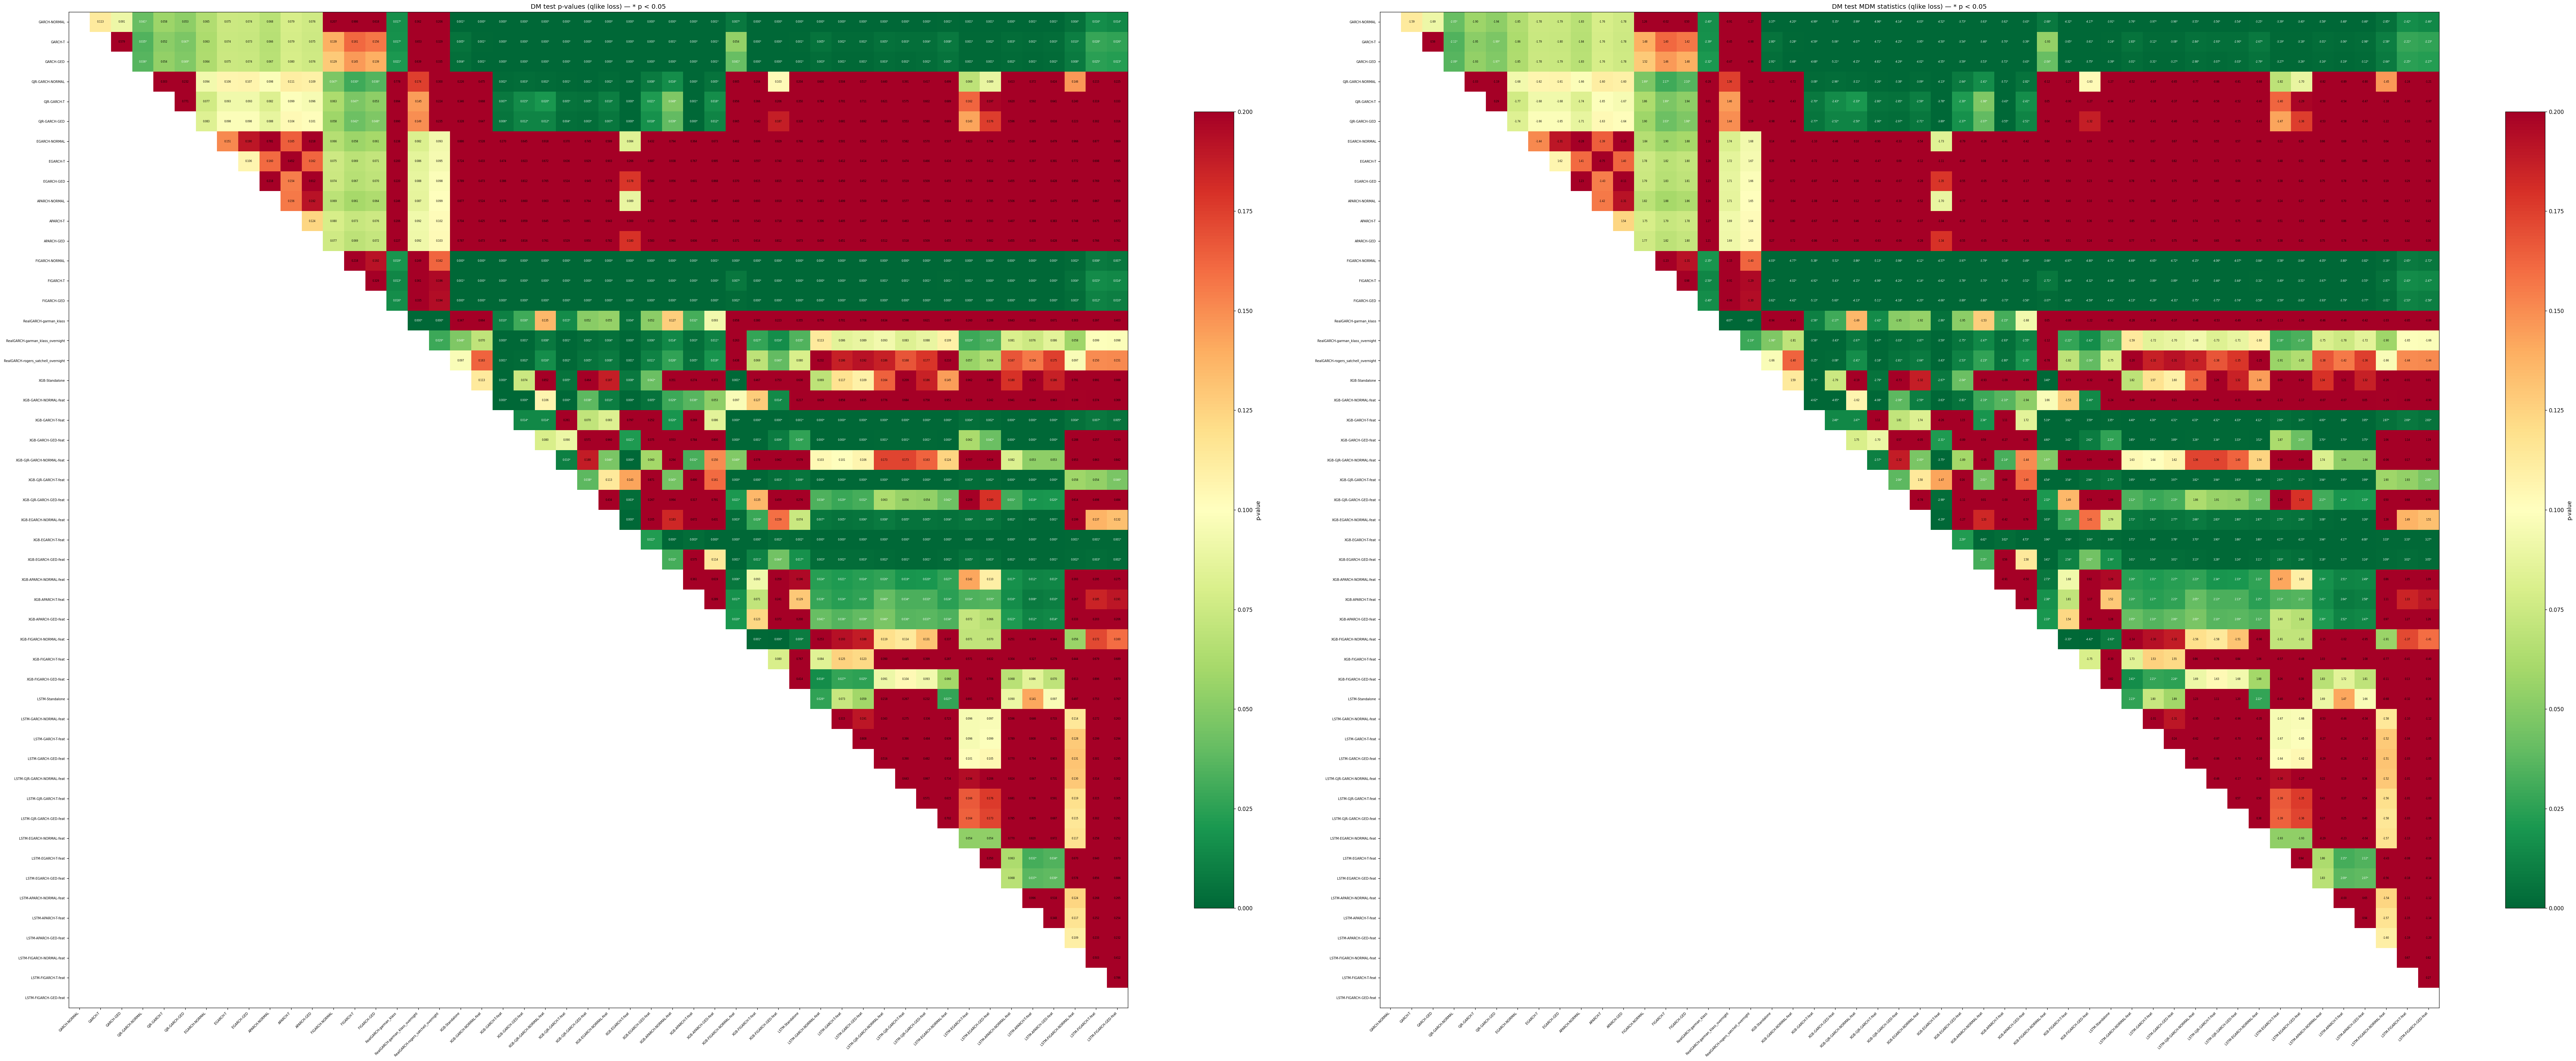

In [43]:
names  = list(all_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)
stats  = dm_stat_df.values.astype(float)

mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)
stats_plot = np.where(mask, np.nan, stats)

fig, axes = plt.subplots(1, 2, figsize=(max(10, n_mods * 0.7) * 2, max(7, n_mods * 0.55)), dpi=120)

for ax, data, title_suffix, fmt in zip(
    axes,
    [pvals_plot, stats_plot],
    ["p-values", "MDM statistics"],
    ["{:.3f}", "{:.2f}"],
):
    im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
    plt.colorbar(im, ax=ax, label="p-value", shrink=0.8)
    ax.set_xticks(range(n_mods))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=6)
    ax.set_yticks(range(n_mods))
    ax.set_yticklabels(names, fontsize=6)
    ax.set_title(f"DM test {title_suffix} ({TEST_LOSS} loss) — * p < {DM_ALPHA}")
    for i in range(n_mods):
        for j in range(i + 1, n_mods):
            val = data[i, j]
            p   = pvals_plot[i, j]
            if not np.isnan(val):
                sig = "*" if (not np.isnan(p) and p < DM_ALPHA) else ""
                ax.text(j, i, fmt.format(val) + sig,
                        ha="center", va="center", fontsize=4.5,
                        color="white" if (not np.isnan(p) and p < 0.05) else "black")

plt.tight_layout()
plt.show()

## 10.2 Model Confidence Set (MCS)

Hansen, Lunde & Nason (2011). Sequential elimination of the worst model until H₀ of equal
predictive accuracy cannot be rejected. Inference via stationary bootstrap (Politis & Romano 1994).

Models with `mcs_pvalue > MCS_ALPHA` belong to the (1 − MCS_ALPHA) MCS.

In [44]:
mcs_result = mcs(
    all_results,
    loss=TEST_LOSS,
    alpha=MCS_ALPHA,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)
print(mcs_result)
print()

# NOTE: this procedure stops at the first non-rejection (Hansen et al. 2011),
# so surviving models share the placeholder 1.0 — NOT a real bootstrap p-value.
# mark_early_stop=True shows those as "—" (early_stop=True). For graded within-set
# p-values that rank the survivors, see the arch.bootstrap.MCS cell below.
mcs_result.summary(mark_early_stop=True).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["in_mcs"],
).format({"mcs_pvalue": "{:.4f}"}, na_rep="—")

MCSResult(alpha=0.05, loss='qlike', n_included=46, models=['GARCH-NORMAL', 'GARCH-T', 'GARCH-GED', 'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED', 'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED', 'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED', 'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED', 'RealGARCH-garman_klass', 'RealGARCH-garman_klass_overnight', 'RealGARCH-rogers_satchell_overnight', 'XGB-Standalone', 'XGB-GARCH-NORMAL-feat', 'XGB-GJR-GARCH-NORMAL-feat', 'XGB-GJR-GARCH-GED-feat', 'XGB-EGARCH-NORMAL-feat', 'XGB-EGARCH-GED-feat', 'XGB-APARCH-NORMAL-feat', 'XGB-APARCH-T-feat', 'XGB-APARCH-GED-feat', 'XGB-FIGARCH-NORMAL-feat', 'XGB-FIGARCH-T-feat', 'XGB-FIGARCH-GED-feat', 'LSTM-Standalone', 'LSTM-GARCH-NORMAL-feat', 'LSTM-GARCH-T-feat', 'LSTM-GARCH-GED-feat', 'LSTM-GJR-GARCH-NORMAL-feat', 'LSTM-GJR-GARCH-T-feat', 'LSTM-GJR-GARCH-GED-feat', 'LSTM-EGARCH-NORMAL-feat', 'LSTM-EGARCH-T-feat', 'LSTM-EGARCH-GED-feat', 'LSTM-APARCH-NORMAL-feat', 'LSTM-APARCH-T-feat', 'LSTM-APARCH-GED-feat', 'LSTM-FIG

,mcs_pvalue,in_mcs,early_stop
GARCH-NORMAL,—,True,True
GARCH-T,—,True,True
XGB-APARCH-NORMAL-feat,—,True,True
XGB-APARCH-T-feat,—,True,True
XGB-APARCH-GED-feat,—,True,True
XGB-FIGARCH-NORMAL-feat,—,True,True
XGB-FIGARCH-T-feat,—,True,True
XGB-FIGARCH-GED-feat,—,True,True
LSTM-Standalone,—,True,True
LSTM-GARCH-NORMAL-feat,—,True,True


In [45]:
arch_mcs_result = arch_mcs(
    all_results,
    loss=TEST_LOSS,
    size=MCS_ALPHA,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)

print(f"arch.bootstrap.MCS — {TEST_LOSS} loss, alpha={MCS_ALPHA}")
print(f"Models in MCS: {arch_mcs_result['in_mcs'].sum()} / {len(arch_mcs_result)}")
print()

# Side-by-side comparison. our_pvalue is "—" for early-stop survivors (placeholder,
# not a real bootstrap value); arch_pvalue gives the graded within-set p-values
# that rank how robustly each model belongs to the MCS. Report arch_pvalue.
comparison = (
    mcs_result.summary(mark_early_stop=True)
    .rename(columns={"mcs_pvalue": "our_pvalue", "in_mcs": "our_in_mcs"})
    .drop(columns=["early_stop"])
)
comparison = comparison.join(
    arch_mcs_result.rename(columns={"mcs_pvalue": "arch_pvalue", "in_mcs": "arch_in_mcs"})
)
comparison.style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["our_in_mcs", "arch_in_mcs"],
).format({"our_pvalue": "{:.4f}", "arch_pvalue": "{:.4f}"}, na_rep="—")

arch.bootstrap.MCS — qlike loss, alpha=0.05
Models in MCS: 46 / 50



,our_pvalue,our_in_mcs,arch_pvalue,arch_in_mcs
GARCH-NORMAL,—,True,0.7665,True
GARCH-T,—,True,0.7665,True
XGB-APARCH-NORMAL-feat,—,True,0.2445,True
XGB-APARCH-T-feat,—,True,0.2220,True
XGB-APARCH-GED-feat,—,True,0.2445,True
XGB-FIGARCH-NORMAL-feat,—,True,0.7665,True
XGB-FIGARCH-T-feat,—,True,0.4925,True
XGB-FIGARCH-GED-feat,—,True,0.2445,True
LSTM-Standalone,—,True,0.5720,True
LSTM-GARCH-NORMAL-feat,—,True,0.7665,True


/var/folders/_v/nfq7618558l9gfbcj7cdk0hm0000gn/T/ipykernel_47829/916799016.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mcs_df["Model"], rotation=45, ha='right', fontsize=7)


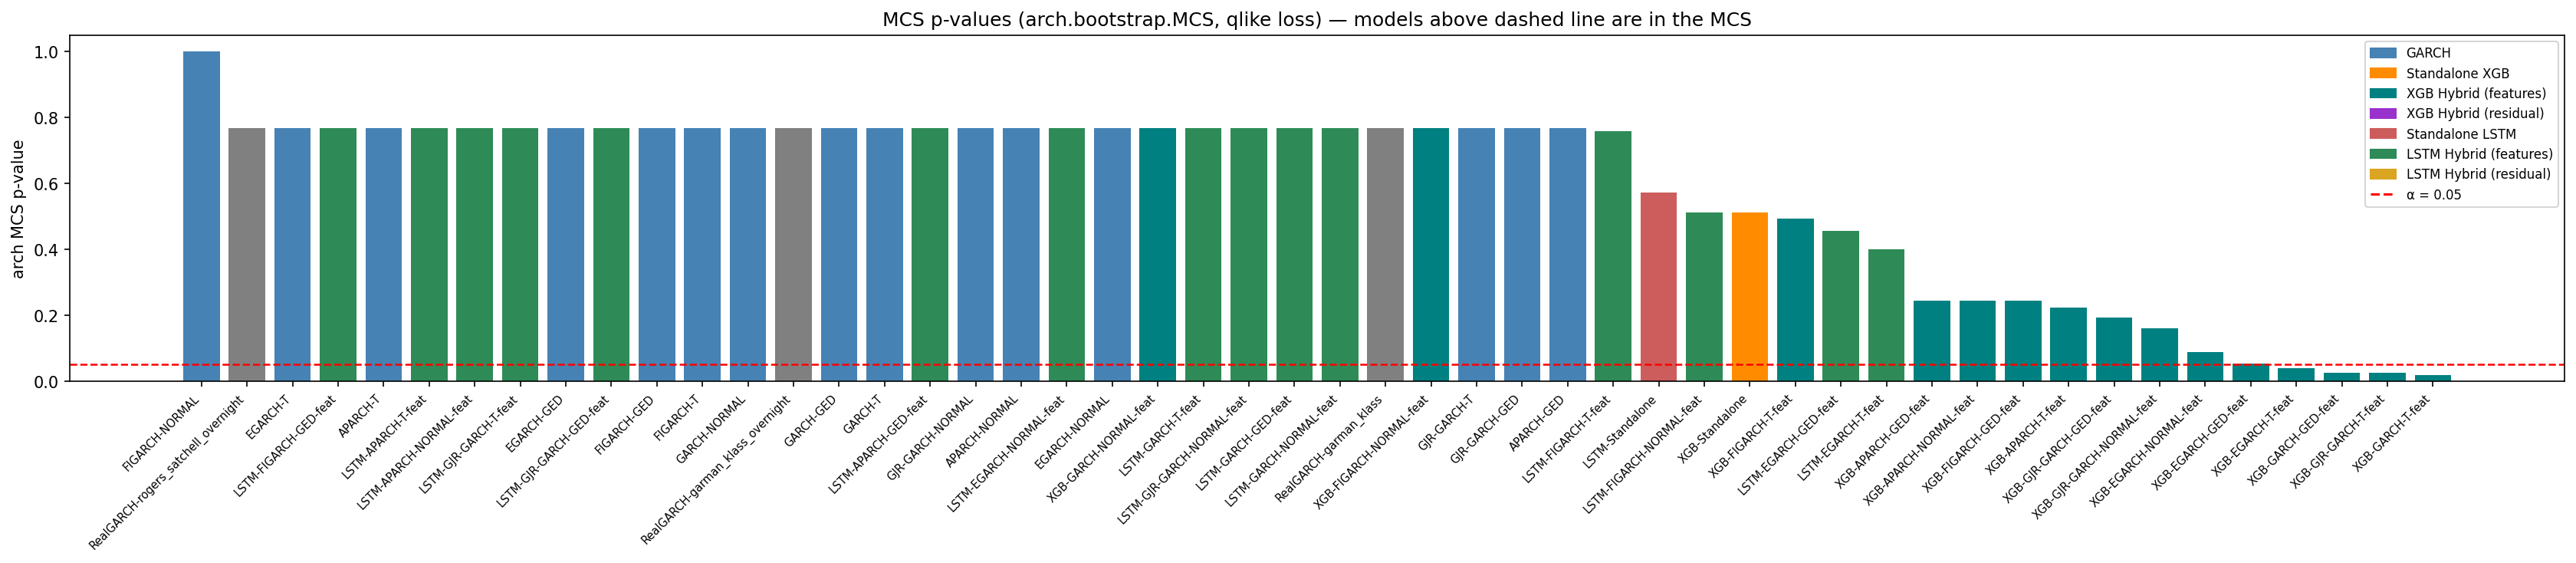

In [46]:
# MCS summary bar chart — arch.bootstrap.MCS p-values per model, coloured by group.
# We plot the arch (graded) p-values rather than our custom-MCS output: the custom
# procedure stops early and assigns a flat placeholder 1.0 to every survivor, which
# would make all in-set bars identical and uninformative. arch gives graded values.
# rename_axis('Model') makes the reset_index column name deterministic regardless of
# how arch names the index.
mcs_df = arch_mcs_result.rename_axis("Model").reset_index()
mcs_df["Group"] = mcs_df["Model"].map(_group)
mcs_df = mcs_df.sort_values("mcs_pvalue", ascending=False)

colors = mcs_df["Group"].map(palette).fillna("gray")

fig, ax = plt.subplots(figsize=(max(8, len(mcs_df) * 0.45), 5), dpi=150)
ax.bar(mcs_df["Model"], mcs_df["mcs_pvalue"], color=colors)
ax.axhline(MCS_ALPHA, color='red', linewidth=1.2, linestyle='--', label=f'α = {MCS_ALPHA}')
ax.set_ylabel("arch MCS p-value")
ax.set_title(f"MCS p-values (arch.bootstrap.MCS, {TEST_LOSS} loss) — models above dashed line are in the MCS")
ax.set_xticklabels(mcs_df["Model"], rotation=45, ha='right', fontsize=7)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(color=color, label=grp) for grp, color in palette.items()]
legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', label=f'α = {MCS_ALPHA}'))
ax.legend(handles=legend_elements, fontsize=8)
plt.tight_layout()
plt.show()